# Sésame, ouvre-toi — Partie 1 : Récupération des données & Analyse exploratoire comparative

**Projet :** Audit du biais algorithmique et de l'équité du système COMPAS (COrrectional Offender Management Profiling for Alternative Sanctions).

**Objectif de ce notebook :** répondre aux étapes 1 et 2 du cahier des charges :
1. Récupérer les données d'intérêt en considérant les **3 tables** fournies afin d'obtenir un contexte suffisamment large.
2. Réaliser une **analyse exploratoire comparative** de ces données, propre, commentée, de qualité publiable.

**Contexte métier :** COMPAS attribue à chaque prévenu un score de risque de récidive (`decile_score`, de 1 à 10). L'enquête ProPublica *"Machine Bias"* (2016) a mis en évidence des écarts de taux d'erreur entre groupes ethniques (cf. affaire Brisha Borden / Vernon Prater citée dans le brief). Ce notebook pose les bases factuelles (données) sur lesquelles s'appuiera l'audit d'équité (SHAP, Chouldechova, AI Act art.13) mené dans les parties suivantes du projet.

---
## Sommaire
1. [Chargement des 3 tables](#1)
2. [Description structurelle de chaque table](#2)
3. [Qualité des données (types, valeurs manquantes, doublons)](#3)
4. [Analyse exploratoire comparative](#4)
   - 4.1 Démographie (sexe, âge, origine ethnique)
   - 4.2 Distribution des scores de risque COMPAS
   - 4.2bis Score de risque violent (`v_decile_score`) par groupe
   - 4.3 Score prédit vs récidive réelle (biais ProPublica)
   - 4.3bis Calibration du score par groupe
   - 4.3ter Taux de classification « haut risque » et erreurs par groupe
   - 4.3quater Disparités entre groupes — synthèse chiffrée
   - 4.4 Antécédents judiciaires (`priors_count`) — variable de confusion
   - 4.5 Corrélations numériques
   - 4.6 Métriques d'équité préliminaires (race)
   - 4.6bis Audit d'équité par sexe (FPR/FNR/Disparate Impact)
5. [Synthèse intermédiaire](#5)


In [1]:
# --- Imports & configuration ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E8ECF0',
    'grid.linewidth':   0.7,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
    'font.family':      'DejaVu Sans',
})

RACE_PALETTE = {
    'African-American': '#E84A5F',
    'Caucasian':        '#2D6A9F',
    'Hispanic':         '#3AAFA9',
    'Other':            '#F0A500',
    'Asian':            '#7B68EE',
    'Native American':  '#A0522D',
}
RACE_ORDER = ['African-American', 'Caucasian', 'Hispanic', 'Other', 'Asian', 'Native American']

def label_bars(ax, fmt='{:.0%}', color='#444', fontsize=9, pad=0.005):
    for p in ax.patches:
        h = p.get_height()
        if h > 0.001:
            ax.text(p.get_x() + p.get_width()/2, h + pad,
                    fmt.format(h), ha='center', va='bottom',
                    fontsize=fontsize, color=color, fontweight='bold')

def label_bars_v(ax, fmt='{:.2f}', color='#444', fontsize=9, pad=0.05):
    for p in ax.patches:
        h = p.get_height()
        if h > 0.001:
            ax.text(p.get_x() + p.get_width()/2, h + pad,
                    fmt.format(h), ha='center', va='bottom',
                    fontsize=fontsize, color=color, fontweight='bold')


<a id="1"></a>
## 1. Récupération et chargement des 3 tables

Le brief précise qu'il faut considérer **3 tables** pour disposer d'un contexte suffisamment large. Le jeu de données mis à disposition (dataset ProPublica *COMPAS Recidivism Risk Score*, ~10 000 prévenus évalués en Floride) se décompose ainsi :

| Table | Fichier | Granularité | Rôle dans l'analyse |
|---|---|---|---|
| **1. Scores bruts COMPAS** | `compas-scores-raw.csv` | 1 ligne par **échelle évaluée** (Récidive générale / Violence / Défaut de présentation), plusieurs lignes par personne | Table source brute du logiciel COMPAS — sert à comprendre *comment* le score est produit (`RawScore`, `DecileScore`, `ScoreText`) |
| **2. Données judiciaires détaillées** | `cox-violent-parsed.csv` (+ variante réduite `cox-violent-parsed_filt.csv`) | 1 ligne par **dossier/charge** d'un prévenu | Table pivot de l'étude ProPublica : croise le score COMPAS avec le casier judiciaire réel et la récidive observée à 2 ans (`is_recid`, `is_violent_recid`) |
| **3. Dataset prêt pour le ML** | `propublica_data_for_fairml.csv` | 1 ligne par **prévenu** (post-nettoyage ProPublica) | Version déjà encodée (one-hot) utilisée comme baseline pour la modélisation et les papiers de fairness-ML |

Ces trois tables sont **complémentaires et non redondantes** : la table 1 explique la mécanique du score, la table 2 permet de confronter score et réalité (récidive), la table 3 est la table d'entraînement finale. Les considérer ensemble permet d'auditer le système de bout en bout (input → score → réalité → équité).


In [2]:
# --- Chargement ---
raw = pd.read_csv("data/compas-scores-raw.csv")               # Table 1 : scores bruts
cox = pd.read_csv("data/cox-violent-parsed.csv")               # Table 2 : version complète
cox_filt = pd.read_csv("data/cox-violent-parsed_filt.csv")     # Table 2bis : version réduite (moins de colonnes administratives)
fairml = pd.read_csv("data/propublica_data_for_fairml.csv")    # Table 3 : dataset ML pré-encodé

print(f"Table 1 - compas-scores-raw       : {raw.shape[0]:>6,} lignes x {raw.shape[1]:>2} colonnes")
print(f"Table 2 - cox-violent-parsed      : {cox.shape[0]:>6,} lignes x {cox.shape[1]:>2} colonnes")
print(f"Table 2b- cox-violent-parsed_filt : {cox_filt.shape[0]:>6,} lignes x {cox_filt.shape[1]:>2} colonnes")
print(f"Table 3 - propublica_fairml       : {fairml.shape[0]:>6,} lignes x {fairml.shape[1]:>2} colonnes")


Table 1 - compas-scores-raw       : 60,843 lignes x 28 colonnes
Table 2 - cox-violent-parsed      : 18,316 lignes x 52 colonnes
Table 2b- cox-violent-parsed_filt : 18,316 lignes x 40 colonnes
Table 3 - propublica_fairml       :  6,172 lignes x 12 colonnes


<a id="2"></a>
## 2. Description structurelle de chaque table


### 2.1 Table 1 — `compas-scores-raw`

Chaque prévenu est évalué sur **3 échelles indépendantes** (`DisplayText`), ce qui explique le format "long" (3 lignes par évaluation).

Nombre de personnes uniques (Person_ID) : 18610


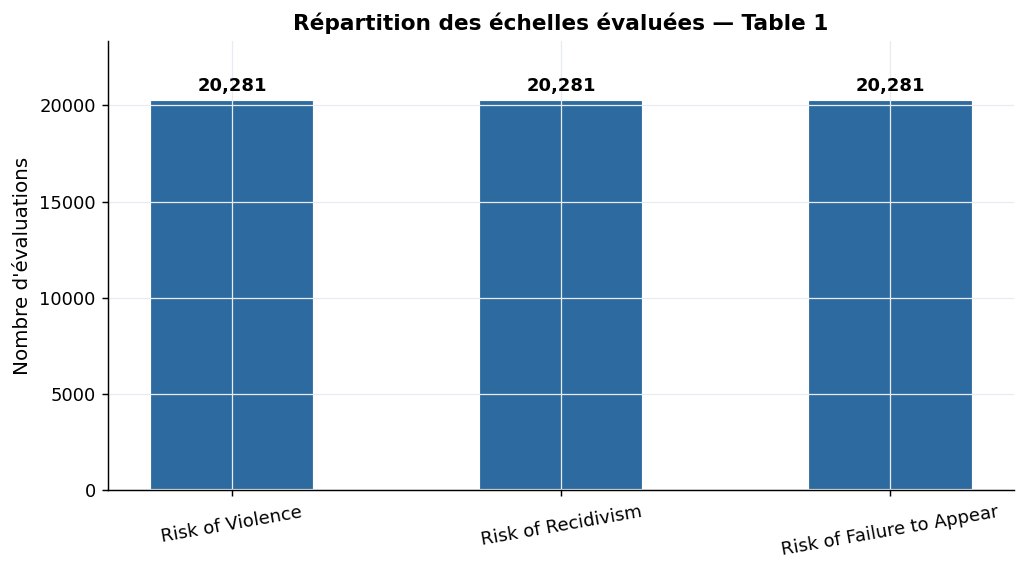

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,ScaleSet_ID,ScaleSet,AssessmentReason,Language,LegalStatus,CustodyStatus,MaritalStatus,Screening_Date,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,22,Risk and Prescreen,Intake,English,Pretrial,Jail Inmate,Single,1/1/13 0:00,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,22,Risk and Prescreen,Intake,English,Pretrial,Jail Inmate,Single,1/1/13 0:00,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,22,Risk and Prescreen,Intake,English,Pretrial,Jail Inmate,Single,1/1/13 0:00,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0


In [3]:
print("Nombre de personnes uniques (Person_ID) :", raw["Person_ID"].nunique())

scale_counts = raw["DisplayText"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(scale_counts.index, scale_counts.values,
              color='#2D6A9F', edgecolor='white', linewidth=1.2, width=0.5)
for p, v in zip(bars, scale_counts.values):
    ax.text(p.get_x() + p.get_width()/2, v + 250,
            f'{v:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title("Répartition des échelles évaluées — Table 1", fontsize=12, fontweight='bold')
ax.set_ylabel("Nombre d'évaluations")
ax.set_xlabel("")
ax.set_ylim(0, scale_counts.max()*1.15)
ax.tick_params(axis='x', rotation=10)
plt.tight_layout()
plt.show()

raw.head(3)


In [4]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60843 entries, 0 to 60842
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person_ID                60843 non-null  int64  
 1   AssessmentID             60843 non-null  int64  
 2   Case_ID                  60843 non-null  int64  
 3   Agency_Text              60843 non-null  object 
 4   LastName                 60843 non-null  object 
 5   FirstName                60843 non-null  object 
 6   MiddleName               15624 non-null  object 
 7   Sex_Code_Text            60843 non-null  object 
 8   Ethnic_Code_Text         60843 non-null  object 
 9   DateOfBirth              60843 non-null  object 
 10  ScaleSet_ID              60843 non-null  int64  
 11  ScaleSet                 60843 non-null  object 
 12  AssessmentReason         60843 non-null  object 
 13  Language                 60843 non-null  object 
 14  LegalStatus           

**Lecture :** on retrouve les 3 échelles à l'identique (~20 281 évaluations chacune). Pour la suite de l'analyse comparative, on isolera l'échelle **"Risk of Recidivism"** (récidive générale), qui est celle mise en cause dans l'affaire Borden/Prater et dans l'étude ProPublica.

In [5]:
# On isole l'échelle "Risk of Recidivism" et on ne garde qu'une ligne par personne
# (une personne peut avoir plusieurs évaluations dans le temps -> on garde la plus récente)
raw_recid = (
    raw[raw["DisplayText"] == "Risk of Recidivism"]
    .sort_values("Screening_Date")
    .drop_duplicates(subset="Person_ID", keep="last")
    .copy()
)
print(f"Table 1 filtrée sur l'échelle 'Risk of Recidivism' : {raw_recid.shape[0]:,} prévenus uniques")
raw_recid[["Person_ID", "Sex_Code_Text", "Ethnic_Code_Text", "RawScore", "DecileScore", "ScoreText"]].head()


Table 1 filtrée sur l'échelle 'Risk of Recidivism' : 18,610 prévenus uniques


,Person_ID,Sex_Code_Text,Ethnic_Code_Text,RawScore,DecileScore,ScoreText
1,50844,Male,Caucasian,-1.06,2,Low
43,50851,Female,African-American,-0.57,6,Medium
40,50841,Female,African-American,-1.00,4,Low
37,50849,Female,Caucasian,-1.67,1,Low
34,50854,Male,Caucasian,-1.66,1,Low


### 2.2 Table 2 — `cox-violent-parsed`

Table pivot de l'étude ProPublica : elle relie le score COMPAS aux données judiciaires (dates d'incarcération, charges, récidive observée). C'est la table qui a servi à démontrer le biais dans l'enquête *Machine Bias*.

In [6]:
print("Nombre d'identifiants uniques (id) :", cox["id"].nunique(), "/ lignes :", cox.shape[0])
print("(Plusieurs lignes par personne = plusieurs charges/dossiers judiciaires)")
cox[["id", "name", "sex", "age", "race", "priors_count", "decile_score",
     "score_text", "is_recid", "is_violent_recid"]].head()


Nombre d'identifiants uniques (id) : 11001 / lignes : 18316
(Plusieurs lignes par personne = plusieurs charges/dossiers judiciaires)


,id,name,sex,age,race,priors_count,decile_score,score_text,is_recid,is_violent_recid
0,1.0,miguel hernandez,Male,69,Other,0,1,Low,0,0
1,2.0,miguel hernandez,Male,69,Other,0,1,Low,0,0
2,3.0,michael ryan,Male,31,Caucasian,0,5,Medium,-1,0
3,4.0,kevon dixon,Male,34,African-American,0,3,Low,1,1
4,5.0,ed philo,Male,24,African-American,4,4,Low,1,0


In [7]:
cox.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Columns: 52 entries, id to event
dtypes: float64(5), int64(14), object(33)
memory usage: 7.3+ MB


La variante `cox-violent-parsed_filt.csv` contient les mêmes lignes mais avec **12 colonnes administratives en moins** (identifiants de dossiers `c_case_number`, `r_case_number`, `vr_case_number`, dates de sortie `out_custody`, etc. — colonnes à faible valeur analytique et fortement trouées). On utilisera cette version allégée comme table de travail principale pour la suite du projet — après avoir retiré les doublons stricts identifiés en section 3 (voir plus bas).

In [8]:
cols_supprimees = set(cox.columns) - set(cox_filt.columns)
print(f"{len(cols_supprimees)} colonnes retirées dans la version filtrée :")
print(sorted(cols_supprimees))


12 colonnes retirées dans la version filtrée :
['c_arrest_date', 'c_case_number', 'c_offense_date', 'compas_screening_date', 'end', 'in_custody', 'out_custody', 'r_case_number', 'r_jail_out', 'start', 'v_screening_date', 'vr_case_number']


### 2.3 Table 3 — `propublica_data_for_fairml`

Version déjà nettoyée et **encodée en one-hot** par ProPublica pour les usages de fairness-ML : chaque ligne = un prévenu, chaque variable ethnique/âge est binarisée. Pratique pour la modélisation, mais moins riche pour l'audit exploratoire (pas de nom, pas de dates, pas de type de charge).

In [9]:
display(fairml.head())
fairml.describe().T


,Two_yr_Recidivism,Number_of_Priors,score_factor,Age_Above_FourtyFive,Age_Below_TwentyFive,African_American,Asian,Hispanic,Native_American,Other,Female,Misdemeanor
0,0,0,0,1,0,0,0,0,0,1,0,0
1,1,0,0,0,0,1,0,0,0,0,0,0
2,1,4,0,0,1,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,0,1
4,1,14,1,0,0,0,0,0,0,0,0,0


,count,mean,std,min,25%,50%,75%,max
Two_yr_Recidivism,6172.0,0.455120,0.498022,0.0,0.0,0.0,1.0,1.0
Number_of_Priors,6172.0,3.246436,4.743770,0.0,0.0,1.0,4.0,38.0
score_factor,6172.0,0.445723,0.497086,0.0,0.0,0.0,1.0,1.0
Age_Above_FourtyFive,6172.0,0.209494,0.406981,0.0,0.0,0.0,0.0,1.0
Age_Below_TwentyFive,6172.0,0.218244,0.413087,0.0,0.0,0.0,0.0,1.0
African_American,6172.0,0.514420,0.499833,0.0,0.0,1.0,1.0,1.0
Asian,6172.0,0.005023,0.070698,0.0,0.0,0.0,0.0,1.0
Hispanic,6172.0,0.082469,0.275101,0.0,0.0,0.0,0.0,1.0
Native_American,6172.0,0.001782,0.042182,0.0,0.0,0.0,0.0,1.0
Other,6172.0,0.055574,0.229115,0.0,0.0,0.0,0.0,1.0


<a id="3"></a>
## 3. Qualité des données : typage, valeurs manquantes, doublons

On vérifie systématiquement, pour chaque table, la présence de valeurs manquantes et de doublons — étape indispensable avant toute comparaison chiffrée entre tables.

In [10]:
def rapport_qualite(df, nom, seuil_affichage=0.0):
    # Affiche un résumé synthétique de la qualité d'une table :
    # % de valeurs manquantes par colonne (colonnes concernées uniquement) et nombre de doublons.
    na = (df.isna().mean() * 100).round(1)
    na = na[na > seuil_affichage].sort_values(ascending=False)
    print(f"--- {nom} ---")
    print(f"Doublons de lignes strictes : {df.duplicated().sum()}")
    if na.empty:
        print("Aucune valeur manquante.")
    else:
        print(f"{len(na)} colonnes avec des valeurs manquantes (top 10) :")
        print(na.head(10).to_string())
    print()

rapport_qualite(raw_recid, "Table 1 (raw_recid)")
rapport_qualite(cox_filt, "Table 2 (cox_filt)")
rapport_qualite(fairml, "Table 3 (fairml)")


--- Table 1 (raw_recid) ---


Doublons de lignes strictes : 0
2 colonnes avec des valeurs manquantes (top 10) :
MiddleName    74.4
ScoreText      0.2

--- Table 2 (cox_filt) ---
Doublons de lignes strictes : 2803
17 colonnes avec des valeurs manquantes (top 10) :
violent_recid         100.0
vr_charge_desc         92.7
vr_offense_date        92.7
vr_charge_degree       92.7
r_days_from_arrest     65.3
r_jail_in              65.3
r_charge_desc          54.8
r_offense_date         54.0
r_charge_degree        54.0
id                     39.9

--- Table 3 (fairml) ---
Doublons de lignes strictes : 5017
Aucune valeur manquante.



**Constats :**
- **Table 1** est quasi complète (peu de champs manquants) car c'est une extraction directe du logiciel COMPAS.
- **Table 2** présente des trous logiques et non aléatoires : les colonnes `r_*` (récidive) sont vides pour les personnes qui n'ont pas récidivé, les colonnes `vr_*` (récidive violente) pour celles dont la récidive n'était pas violente. **Ce ne sont pas des données manquantes à corriger, mais l'absence de l'événement lui-même** — un point important à ne pas traiter par une imputation naïve lors du feature engineering.
- **Table 3** est intégralement complète : c'est un dataset de modélisation déjà nettoyé par ProPublica, sans valeur manquante ni identifiant.
- **Doublons de lignes strictes** (calculés ci-dessus) : la Table 2 en compte 2 803 sur 18 316 lignes (~15 %), et surtout la **Table 3 en compte 5 017 sur 6 172 lignes (~81 %)**. Ces deux cas ont des origines différentes : pour la **Table 2**, les lignes dupliquées correspondent exactement aux lignes où `id` est manquant (39,9 % de la colonne) — un artefact du pipeline source (échec de jointure côté ProPublica), pas de vraies observations répétées. On les retire ci-dessous avant de poursuivre l'analyse. Pour la **Table 3**, le taux élevé s'explique plutôt par le faible nombre de colonnes et leur cardinalité réduite (variables binaires/discrètes) — plusieurs prévenus partagent le même vecteur de features (~1 150 combinaisons distinctes pour 6 172 lignes) ; ce n'est pas une erreur de chargement mais une limite de richesse informative à garder en tête pour la modélisation.


In [11]:
# La rapport de qualité ci-dessus montre 2 803 doublons stricts dans cox_filt (~15 % des lignes).
# Vérification : ce sont exactement les lignes où `id` est manquant -> artefact du pipeline source
# (échec de jointure côté ProPublica), pas de vraies observations répétées à conserver.
dup_mask = cox_filt.duplicated(keep=False)
print(f"Lignes dans un groupe de doublons stricts : {dup_mask.sum():,}")
print(f"Parmi elles, part avec id manquant : {cox_filt.loc[dup_mask, 'id'].isna().mean():.1%}")

n_avant = len(cox_filt)
cox_filt = cox_filt.drop_duplicates().reset_index(drop=True)
n_apres = len(cox_filt)
print(f"\ncox_filt dédoublonné : {n_avant:,} -> {n_apres:,} lignes "
      f"({n_avant - n_apres:,} doublons stricts supprimés, soit {(n_avant - n_apres)/n_avant:.1%})")
print("C'est cette version dédoublonnée qui sera utilisée dans la suite du notebook (section 4).")


Lignes dans un groupe de doublons stricts : 4,371
Parmi elles, part avec id manquant : 100.0%

cox_filt dédoublonné : 18,316 -> 15,513 lignes (2,803 doublons stricts supprimés, soit 15.3%)
C'est cette version dédoublonnée qui sera utilisée dans la suite du notebook (section 4).


<a id="4"></a>
## 4. Analyse exploratoire comparative

L'objectif de cette section est de comparer les 3 sources entre elles sur les axes qui structureront l'audit d'équité : démographie, score de risque, récidive réelle, antécédents.


### 4.1 Démographie comparée : sexe, âge, origine ethnique

On reconstruit une variable `race` homogène pour la table 3 (encodée en dummies) afin de pouvoir comparer les 3 tables sur la même base.

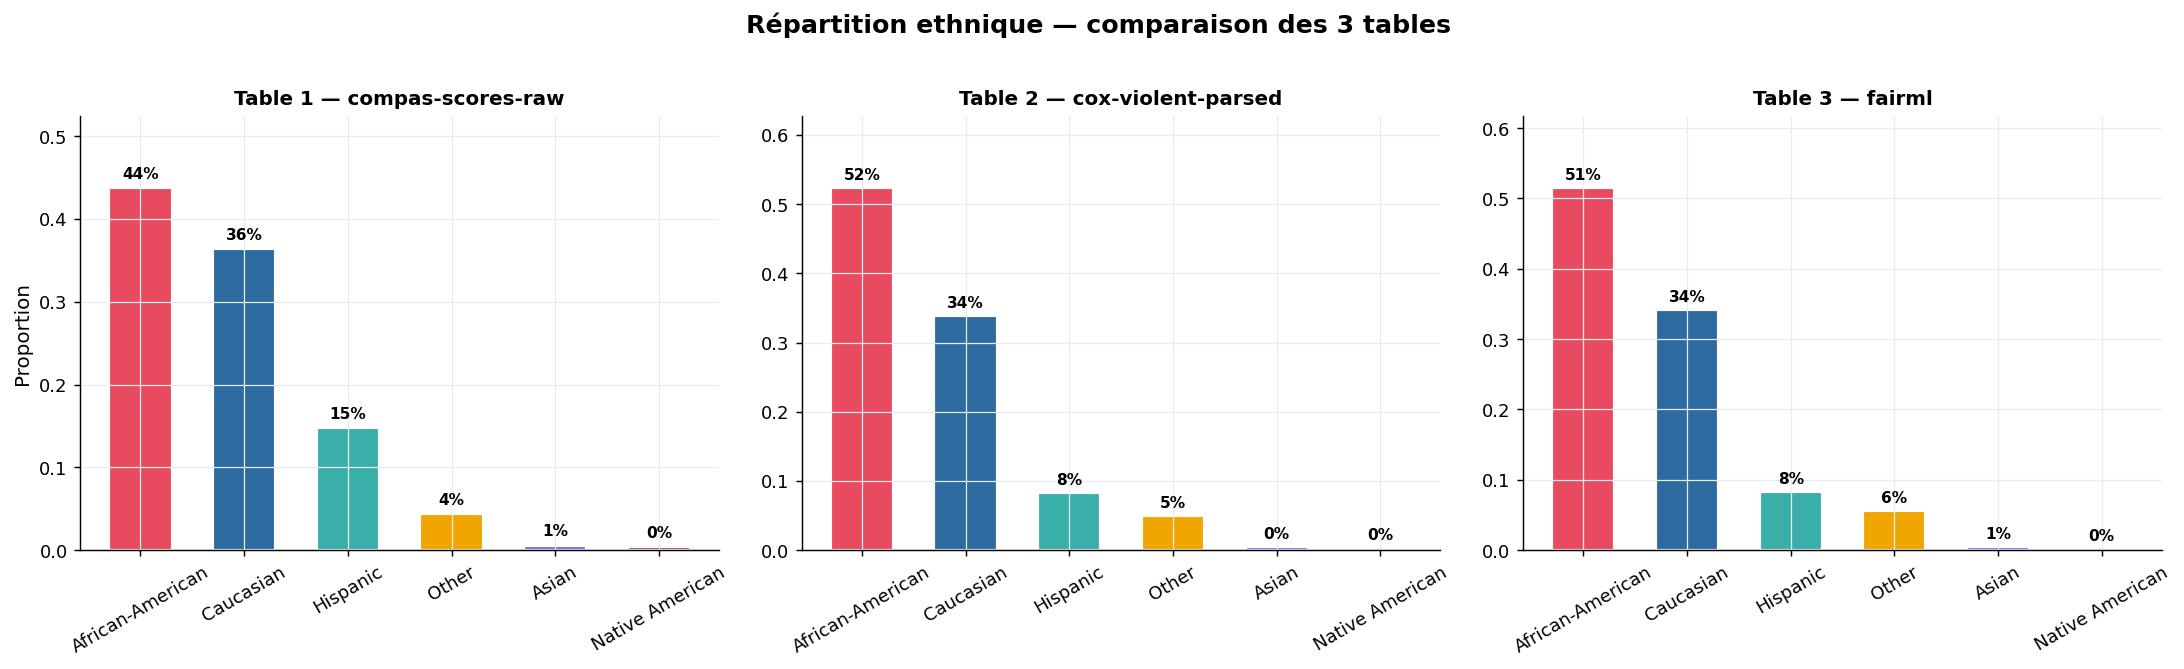

In [12]:
race_cols = ["African_American", "Asian", "Hispanic", "Native_American", "Other"]
fairml_race = fairml[race_cols].idxmax(axis=1)
fairml["race"] = np.where(fairml[race_cols].sum(axis=1) == 0, "Caucasian", fairml_race)
fairml["race"] = fairml["race"].replace({
    "African_American": "African-American", "Native_American": "Native American"
})

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Répartition ethnique — comparaison des 3 tables", fontsize=14, fontweight='bold', y=1.02)

tables = [
    (raw_recid, "Ethnic_Code_Text", "Table 1 — compas-scores-raw"),
    (cox_filt,  "race",                "Table 2 — cox-violent-parsed"),
    (fairml,    "race",                "Table 3 — fairml"),
]
colors = [RACE_PALETTE.get(r, '#AAAAAA') for r in RACE_ORDER]

for ax, (df, col, titre) in zip(axes, tables):
    races = [r for r in RACE_ORDER if r in df[col].values]
    counts = df[col].value_counts().reindex(races)
    pcts = counts / counts.sum()
    bars = ax.bar(races, pcts.values,
                  color=[RACE_PALETTE.get(r, '#AAAAAA') for r in races],
                  edgecolor='white', linewidth=1.2, width=0.6)
    for p, v in zip(bars, pcts.values):
        ax.text(p.get_x() + p.get_width()/2, v + 0.008,
                f'{v:.0%}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
    ax.set_title(titre, fontsize=11)
    ax.set_ylabel("Proportion" if ax == axes[0] else "")
    ax.set_ylim(0, pcts.max() * 1.2)
    ax.tick_params(axis='x', rotation=30)
    ax.set_xlabel("")

plt.tight_layout()
plt.show()


**Lecture :** la structure démographique est **cohérente entre les 3 tables** — les Afro-Américains et les Caucasiens forment les deux groupes majoritaires (~80 % des effectifs cumulés), avec une sur-représentation des Afro-Américains par rapport à leur poids dans la population générale de Floride (~17 %). Ce déséquilibre de représentation est un point de vigilance pour l'audit d'équité : un déséquilibre des classes n'est pas en soi un biais, mais il **réduit la puissance statistique** des métriques de fairness calculées sur les groupes minoritaires (Asiatique, Amérindien) et justifiera un focus sur les deux groupes majoritaires dans les parties suivantes.

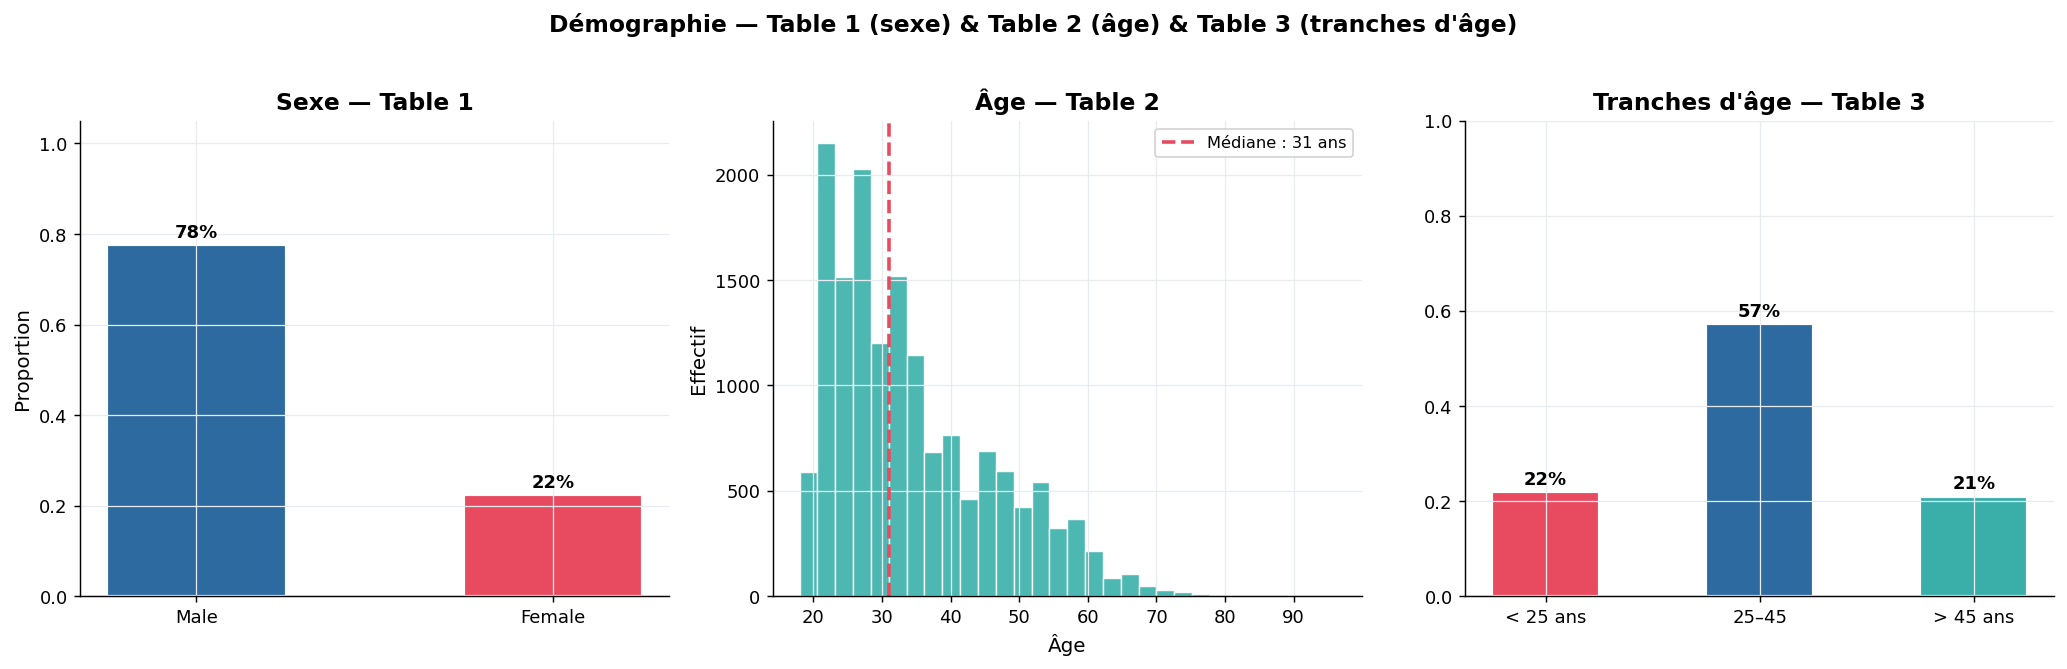

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Démographie — Table 1 (sexe) & Table 2 (âge) & Table 3 (tranches d'âge)",
             fontsize=13, fontweight='bold', y=1.02)

# Sexe (Table 1)
sex_counts = raw_recid["Sex_Code_Text"].value_counts()
colors_sex = ['#2D6A9F', '#E84A5F']
axes[0].bar(sex_counts.index, sex_counts.values / sex_counts.sum(),
            color=colors_sex, edgecolor='white', linewidth=1.2, width=0.5)
for p in axes[0].patches:
    h = p.get_height()
    axes[0].text(p.get_x() + p.get_width()/2, h + 0.008,
                 f'{h:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title("Sexe — Table 1")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 1.05)

# Âge continu (Table 2)
axes[1].hist(cox_filt["age"].dropna(), bins=30, color='#3AAFA9',
             edgecolor='white', linewidth=0.8, alpha=0.9)
axes[1].axvline(cox_filt["age"].median(), color='#E84A5F', linewidth=2,
                linestyle='--', label=f'Médiane : {cox_filt["age"].median():.0f} ans')
axes[1].set_title("Âge — Table 2")
axes[1].set_xlabel("Âge")
axes[1].set_ylabel("Effectif")
axes[1].legend(fontsize=9)

# Tranches d'âge (Table 3)
age_map = fairml[["Age_Below_TwentyFive", "Age_Above_FourtyFive"]].idxmax(axis=1)
age_map = age_map.mask(fairml[["Age_Below_TwentyFive","Age_Above_FourtyFive"]].sum(axis=1)==0, "25–45")
age_map = age_map.replace({"Age_Below_TwentyFive": "< 25 ans", "Age_Above_FourtyFive": "> 45 ans"})
order3 = ["< 25 ans", "25–45", "> 45 ans"]
ac = age_map.value_counts().reindex(order3)
axes[2].bar(ac.index, ac.values / ac.sum(),
            color=['#E84A5F','#2D6A9F','#3AAFA9'], edgecolor='white', linewidth=1.2, width=0.5)
for p in axes[2].patches:
    h = p.get_height()
    axes[2].text(p.get_x() + p.get_width()/2, h + 0.008,
                 f'{h:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].set_title("Tranches d'âge — Table 3")
axes[2].set_ylabel("")
axes[2].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


**Lecture :** la population est majoritairement masculine (répartition classique d'une population pénale), et la classe d'âge 25-45 ans domine dans les 3 sources — cohérence démographique confirmée entre les tables.

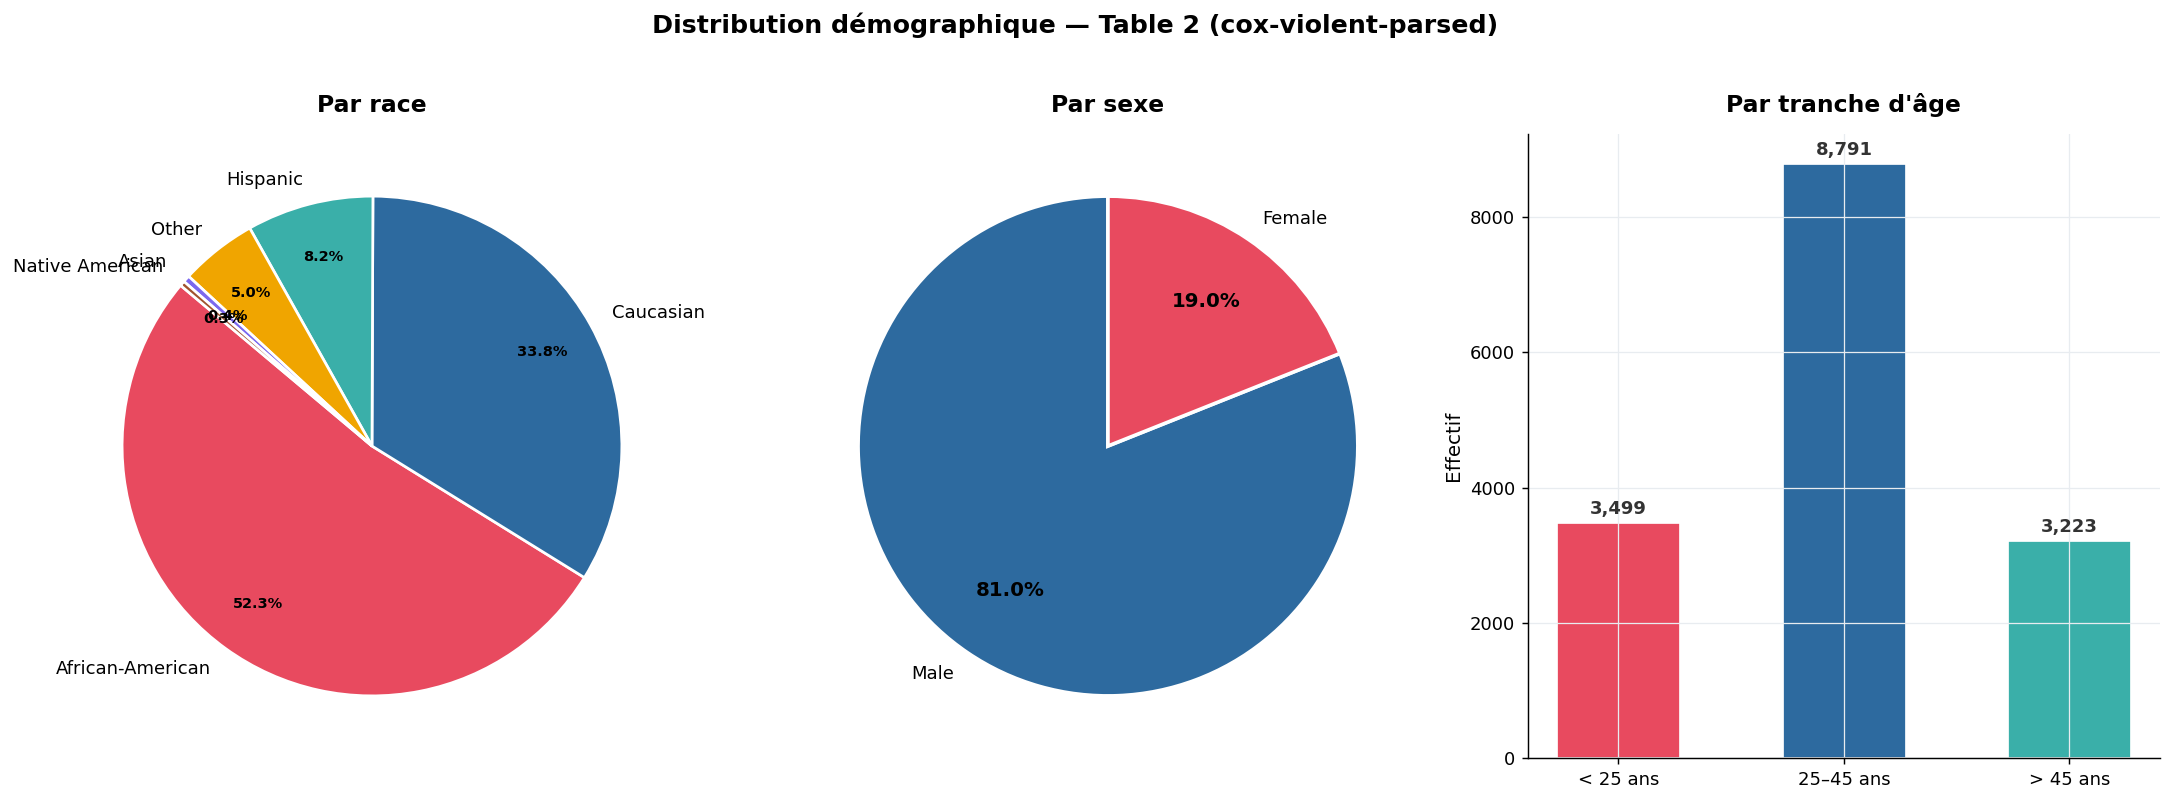

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Distribution démographique — Table 2 (cox-violent-parsed)",
             fontsize=14, fontweight='bold', y=1.02)

# Race
race_counts = cox_filt["race"].value_counts()
wedge_colors = [RACE_PALETTE.get(r, '#AAAAAA') for r in race_counts.index]
wedges, texts, autotexts = axes[0].pie(
    race_counts.values, labels=race_counts.index,
    autopct='%1.1f%%', startangle=140,
    colors=wedge_colors, pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts: at.set_fontsize(8); at.set_fontweight('bold')
axes[0].set_title("Par race", pad=12)

# Sexe
sex_counts = cox_filt["sex"].value_counts()
wedges2, texts2, autotexts2 = axes[1].pie(
    sex_counts.values, labels=sex_counts.index,
    autopct='%1.1f%%', startangle=90,
    colors=['#2D6A9F', '#E84A5F'],
    pctdistance=0.7,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts2: at.set_fontsize(11); at.set_fontweight('bold')
axes[1].set_title("Par sexe", pad=12)

# Âge
age_order = ["Less than 25", "25 - 45", "Greater than 45"]
age_labels = ["< 25 ans", "25–45 ans", "> 45 ans"]
age_counts = cox_filt["age_cat"].value_counts().reindex(age_order).fillna(0)
bars = axes[2].bar(age_labels, age_counts.values,
                   color=['#E84A5F', '#2D6A9F', '#3AAFA9'],
                   edgecolor='white', linewidth=1.5, width=0.55)
for p in bars:
    axes[2].text(p.get_x() + p.get_width()/2, p.get_height() + 60,
                 f'{int(p.get_height()):,}', ha='center', va='bottom',
                 fontsize=10, fontweight='bold', color='#333')
axes[2].set_title("Par tranche d'âge", pad=12)
axes[2].set_ylabel("Effectif")
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


**Lecture :** les Afro-Américains représentent ~52 % de la population du dataset (après retrait des doublons stricts, cf. section 3), les Caucasiens ~34 %. La population est à ~81 % masculine et concentrée sur la tranche 25–45 ans — profil typique d'une population pénale.

### 4.2 Distribution des scores de risque COMPAS

On compare la distribution du score global (`DecileScore`/`decile_score`, 1 à 10) puis on la croise avec l'origine ethnique — c'est le graphique qui a permis à ProPublica de mettre en évidence des distributions structurellement différentes selon les groupes.

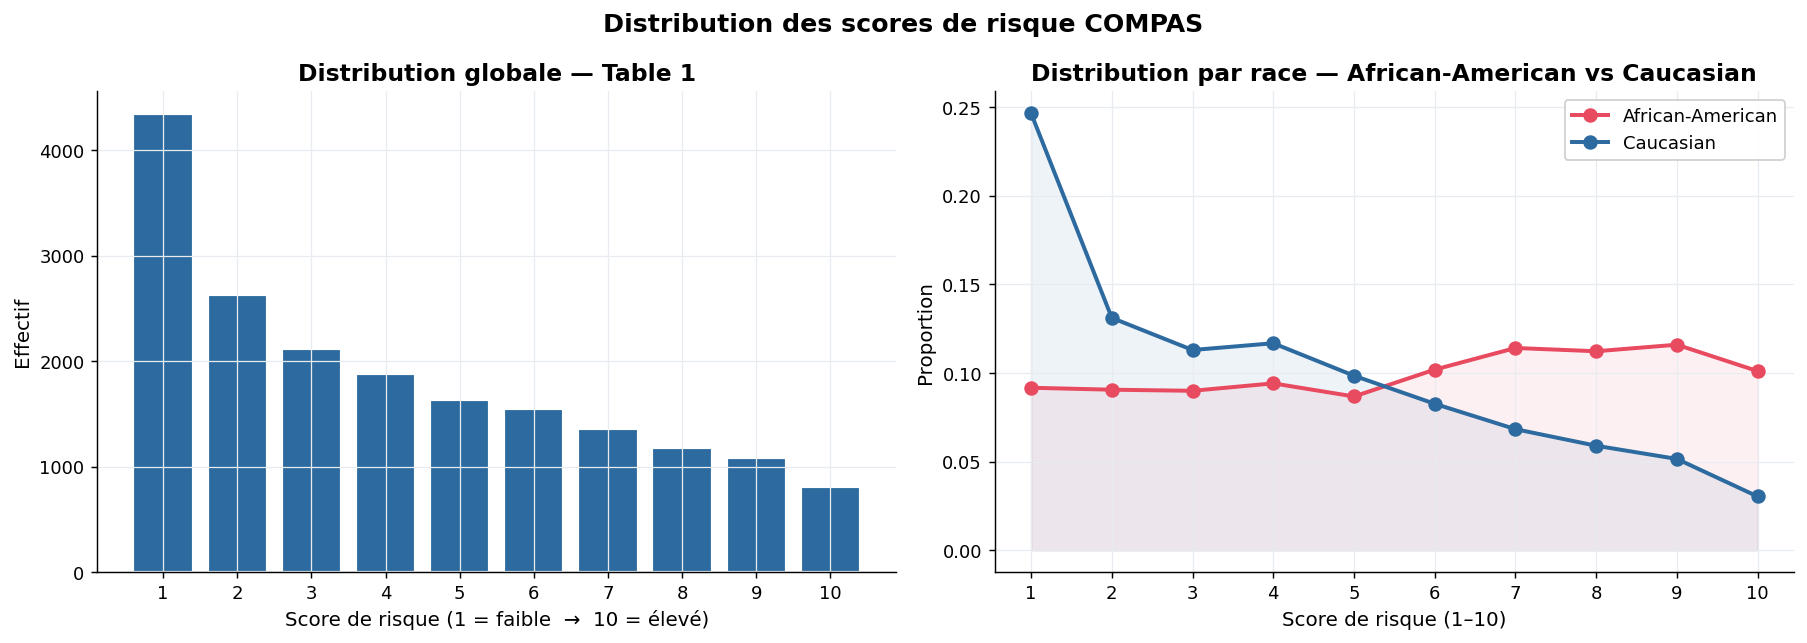

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des scores de risque COMPAS", fontsize=14, fontweight='bold')

# Distribution globale
decile_counts = raw_recid[raw_recid["DecileScore"] > 0]["DecileScore"].value_counts().sort_index()
# DecileScore == -1 signale une évaluation non aboutie (hors échelle 1-10), exclue du graphique
axes[0].bar(decile_counts.index, decile_counts.values,
            color='#2D6A9F', edgecolor='white', linewidth=1.2)
axes[0].set_title("Distribution globale — Table 1")
axes[0].set_xlabel("Score de risque (1 = faible  →  10 = élevé)")
axes[0].set_ylabel("Effectif")
axes[0].set_xticks(range(1, 11))

# Par groupe ethnique (AA vs Caucasian)
for race, color in [("African-American", '#E84A5F'), ("Caucasian", '#2D6A9F')]:
    sub = cox_filt[cox_filt["race"] == race]["decile_score"]
    axes[1].plot(range(1, 11),
                 [sub.value_counts().get(i, 0) / len(sub) for i in range(1, 11)],
                 marker='o', linewidth=2.2, markersize=7,
                 color=color, label=race)

axes[1].set_title("Distribution par race — African-American vs Caucasian")
axes[1].set_xlabel("Score de risque (1–10)")
axes[1].set_ylabel("Proportion")
axes[1].set_xticks(range(1, 11))
axes[1].legend(frameon=True, framealpha=0.9, fontsize=10)
axes[1].fill_between(range(1, 11),
    [cox_filt[cox_filt["race"]=="African-American"]["decile_score"].value_counts().get(i,0)
     / len(cox_filt[cox_filt["race"]=="African-American"]) for i in range(1,11)],
    alpha=0.08, color='#E84A5F')
axes[1].fill_between(range(1, 11),
    [cox_filt[cox_filt["race"]=="Caucasian"]["decile_score"].value_counts().get(i,0)
     / len(cox_filt[cox_filt["race"]=="Caucasian"]) for i in range(1,11)],
    alpha=0.08, color='#2D6A9F')

plt.tight_layout()
plt.show()


**Lecture — constat central de l'affaire Borden/Prater reproduit à l'échelle du dataset :** la distribution du score chez les prévenus **Caucasiens** est fortement concentrée sur les scores faibles (forme décroissante), alors que celle des prévenus **Afro-Américains** est presque uniforme sur l'ensemble de l'échelle 1-10. Autrement dit, à nombre égal de prévenus, un Afro-Américain a une probabilité bien plus élevée de recevoir un score "élevé" qu'un Caucasien — **avant même** de savoir s'il a effectivement récidivé. C'est précisément ce déséquilibre qui sera quantifié avec des indicateurs d'équité (égalité des chances, parité démographique) et expliqué via SHAP dans les parties suivantes.

### 4.2bis Score de risque violent (`v_decile_score`) par groupe

COMPAS produit aussi un score spécifique de risque de **récidive violente**. On vérifie si le même déséquilibre s'y retrouve.

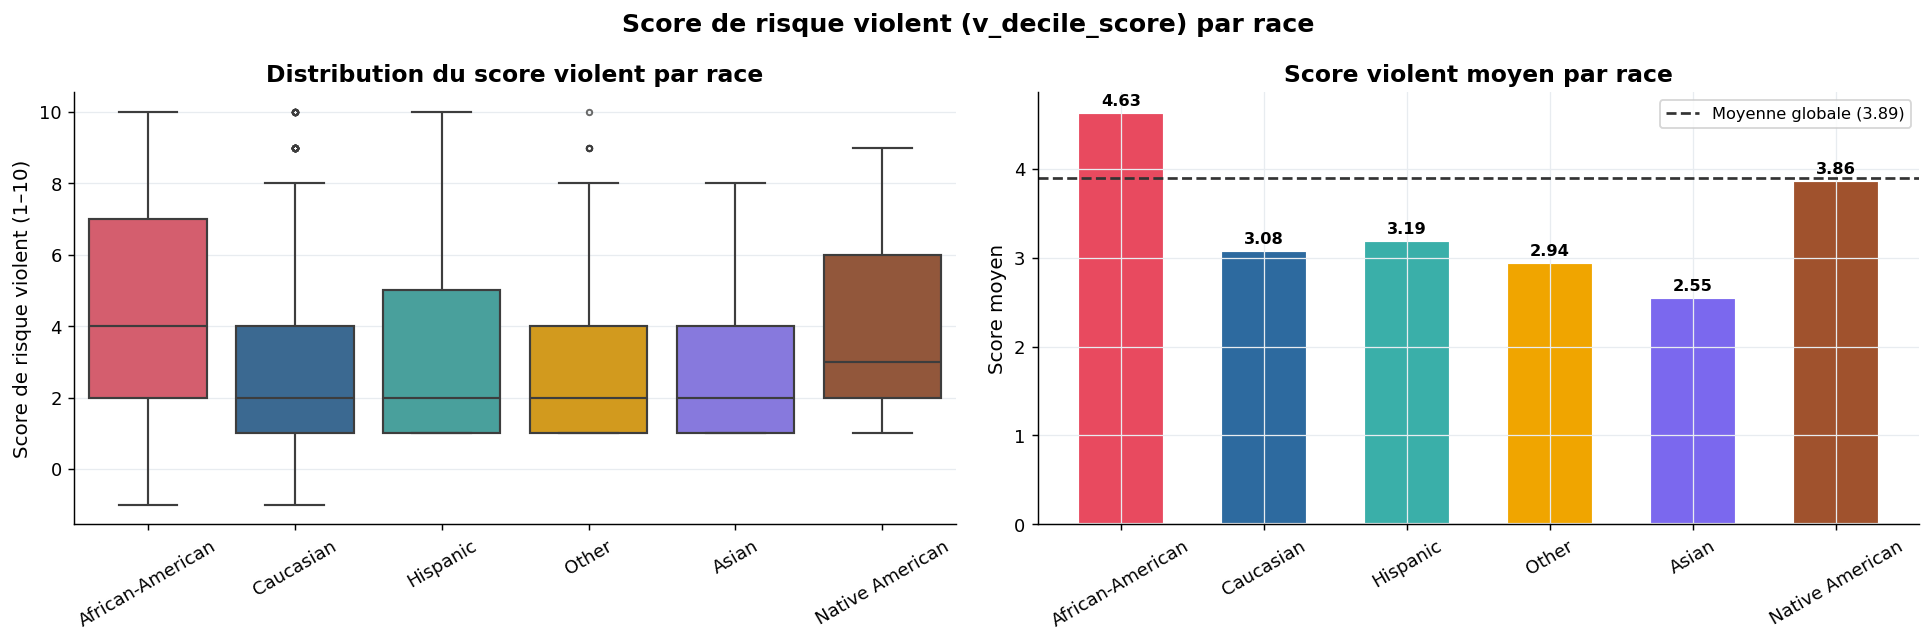

In [16]:
RACE_ORDER = ["African-American", "Caucasian", "Hispanic", "Other", "Asian", "Native American"]
races_presentes = [r for r in RACE_ORDER if r in cox_filt["race"].values]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Score de risque violent (v_decile_score) par race", fontsize=14, fontweight='bold')

# Boxplot score violent
df_box = cox_filt[cox_filt["race"].isin(races_presentes)].copy()
sns.boxplot(data=df_box, x="race", y="v_decile_score",
            order=races_presentes,
            palette=RACE_PALETTE, ax=axes[0],
            linewidth=1.2, flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[0].set_title("Distribution du score violent par race")
axes[0].set_xlabel("")
axes[0].set_ylabel("Score de risque violent (1–10)")
axes[0].tick_params(axis='x', rotation=30)

# Score moyen violent par race
v_means = df_box.groupby("race")["v_decile_score"].mean().reindex(races_presentes)
bars = axes[1].bar(v_means.index,
                   v_means.values,
                   color=[RACE_PALETTE.get(r, '#AAAAAA') for r in v_means.index],
                   edgecolor='white', linewidth=1.2, width=0.6)
axes[1].axhline(cox_filt["v_decile_score"].mean(), color='#333', linewidth=1.5,
                linestyle='--', label=f'Moyenne globale ({cox_filt["v_decile_score"].mean():.2f})')
for p, v in zip(bars, v_means.values):
    axes[1].text(p.get_x() + p.get_width()/2, v + 0.05,
                 f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title("Score violent moyen par race")
axes[1].set_ylabel("Score moyen")
axes[1].set_xlabel("")
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


**Lecture :** le déséquilibre observé sur le score général se retrouve sur le score violent — les Afro-Américains présentent un score violent moyen supérieur à celui des Caucasiens. Ce signal renforce la nécessité d'un audit séparé des deux composantes du score dans les parties suivantes.

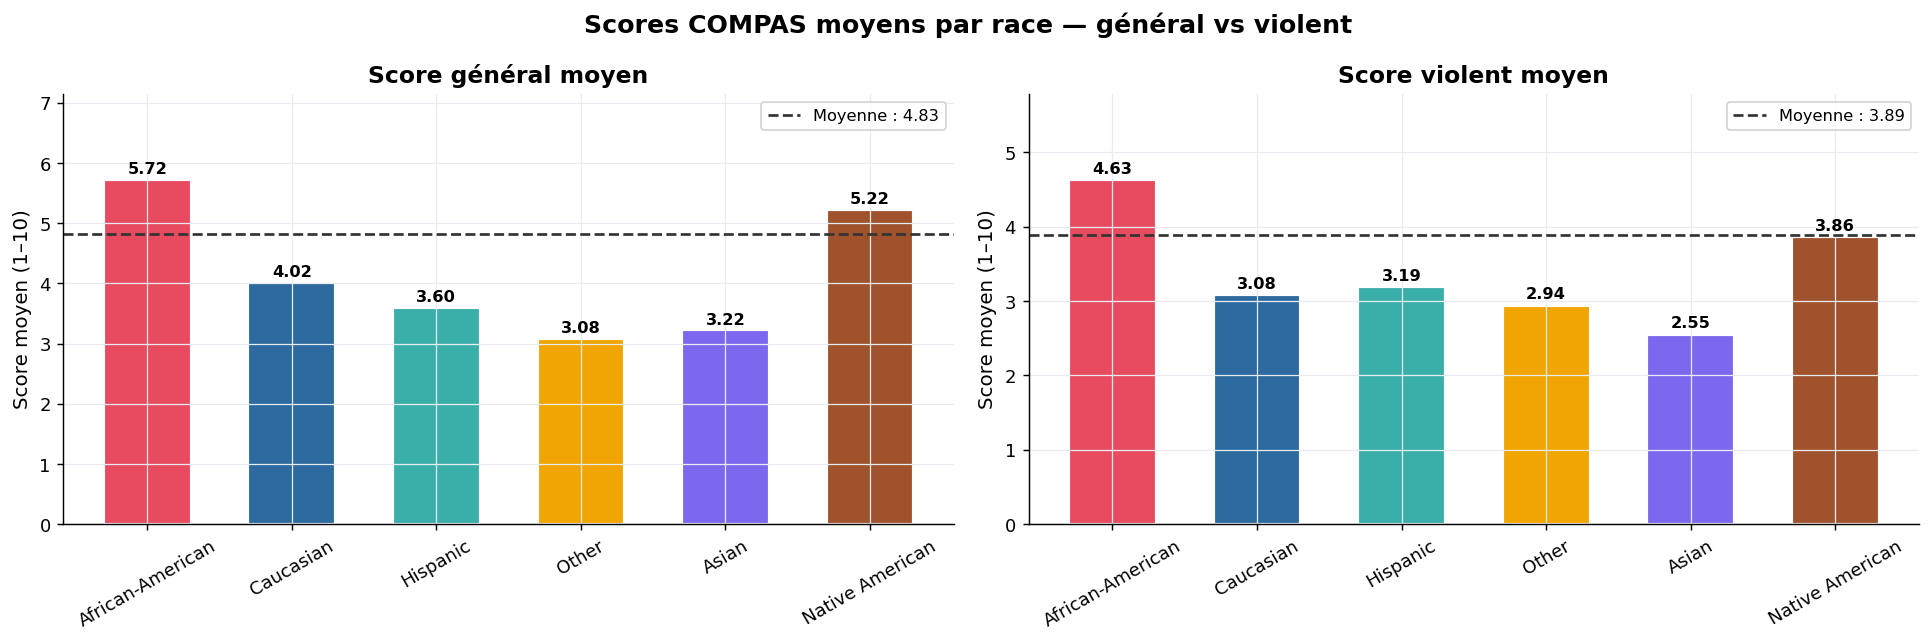

Scores moyens par race :


,Score général,Score violent
race,,
African-American,5.72,4.63
Caucasian,4.02,3.08
Hispanic,3.60,3.19
Other,3.08,2.94
Asian,3.22,2.55
Native American,5.22,3.86


In [17]:
score_by_race = (
    cox_filt[cox_filt["race"].isin(races_presentes)]
    .groupby("race")[["decile_score", "v_decile_score"]]
    .mean().reindex(races_presentes).round(2)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Scores COMPAS moyens par race — général vs violent", fontsize=14, fontweight='bold')

for ax, col, titre, mean_col in [
    (axes[0], "decile_score",   "Score général moyen",  '#2D6A9F'),
    (axes[1], "v_decile_score", "Score violent moyen",  '#E84A5F'),
]:
    data = score_by_race[col]
    bars = ax.bar(data.index, data.values,
                  color=[RACE_PALETTE.get(r, '#AAAAAA') for r in data.index],
                  edgecolor='white', linewidth=1.2, width=0.6)
    ax.axhline(cox_filt[col].mean(), color='#333', linewidth=1.5, linestyle='--',
               label=f'Moyenne : {cox_filt[col].mean():.2f}')
    for p, v in zip(bars, data.values):
        ax.text(p.get_x() + p.get_width()/2, v + 0.05,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(titre)
    ax.set_ylabel("Score moyen (1–10)")
    ax.set_xlabel("")
    ax.set_ylim(0, data.max() * 1.25)
    ax.legend(fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

print("Scores moyens par race :")
display(score_by_race.rename(columns={"decile_score": "Score général", "v_decile_score": "Score violent"}))


**Lecture :** sur les deux composantes du score (général et violent), les Afro-Américains et les Natifs Américains présentent les scores moyens les plus élevés (5,72 et 5,22 en score général, 4,63 et 3,86 en score violent) ; les Caucasiens se situent en position médiane (4,02 / 3,08), les scores les plus bas revenant à `Other` sur l'échelle générale (3,08) et à `Asian` sur l'échelle violente (2,55). Ce déséquilibre entre Afro-Américains/Natifs Américains d'un côté et les autres groupes de l'autre est cohérent entre les deux échelles, ce qui renforce le signal de biais systématique plutôt qu'un artefact isolé.

### 4.3 Score prédit vs récidive réelle : reproduction du biais ProPublica

La question clé n'est pas seulement "qui reçoit quel score" mais **"le score prédit-il correctement la récidive, et de la même façon pour tous les groupes ?"**. On croise ici `score_text` (prédiction COMPAS) et `is_recid` (récidive réelle observée à 2 ans).

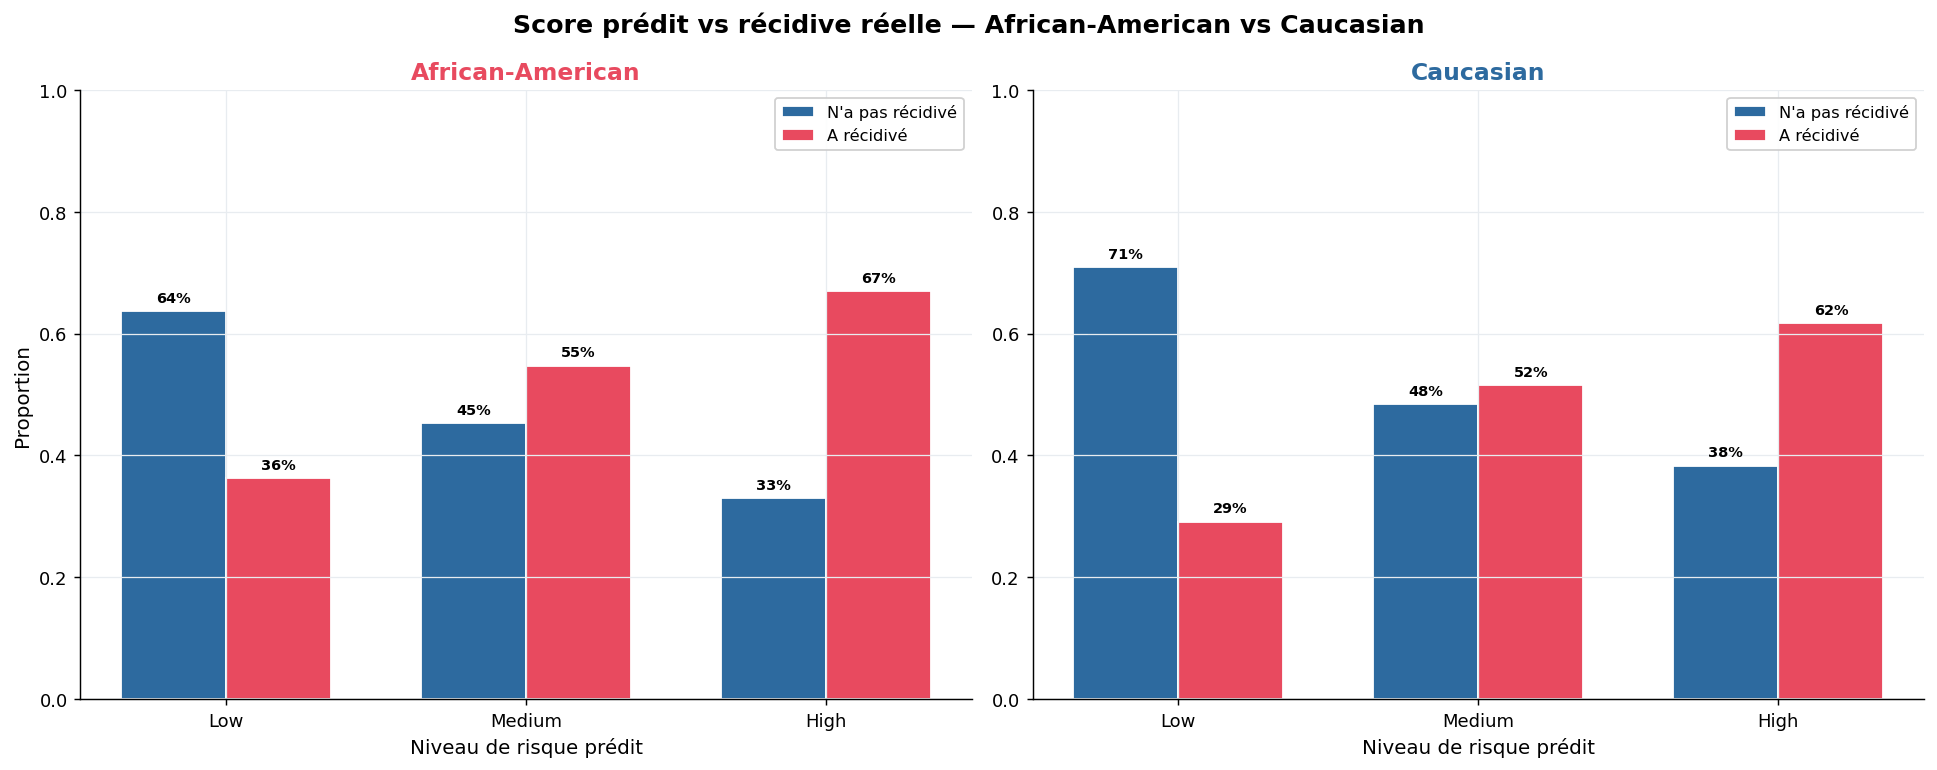

In [18]:
# Fenêtre de 30 jours autour du screening COMPAS (méthodologie ProPublica) : on exclut les charges
# trop éloignées de la date d'évaluation, qui ne sont pas fiables comme mesure de "récidive" liée au score.
screening_ok = cox_filt["days_b_screening_arrest"].between(-30, 30)
# decile_score == -1 signale une évaluation non aboutie (même artefact que dans la Table 1) -> exclu
cox_valid = cox_filt[(cox_filt["is_recid"] != -1) & screening_ok & (cox_filt["decile_score"] > 0)].copy()
cox_valid["recidive_reelle"] = cox_valid["is_recid"].map({0: "N'a pas récidivé", 1: "A récidivé"})

taux = (
    cox_valid[cox_valid["race"].isin(["African-American", "Caucasian"])]
    .groupby(["race", "score_text", "recidive_reelle"])
    .size().reset_index(name="n")
)
taux["prop"] = taux.groupby(["race", "score_text"])["n"].transform(lambda x: x / x.sum())

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Score prédit vs récidive réelle — African-American vs Caucasian",
             fontsize=14, fontweight='bold')

score_order = ["Low", "Medium", "High"]
recid_colors = {"N'a pas récidivé": '#2D6A9F', "A récidivé": '#E84A5F'}

for ax, race in zip(axes, ["African-American", "Caucasian"]):
    sub = taux[taux["race"] == race]
    x = range(len(score_order))
    width = 0.35
    for j, (recid, color) in enumerate(recid_colors.items()):
        vals = [sub[(sub["score_text"]==s) & (sub["recidive_reelle"]==recid)]["prop"].values
                for s in score_order]
        vals = [v[0] if len(v) > 0 else 0 for v in vals]
        offset = (j - 0.5) * width
        bars = ax.bar([xi + offset for xi in x], vals, width,
                      label=recid, color=color, edgecolor='white', linewidth=1)
        for p, v in zip(bars, vals):
            if v > 0.03:
                ax.text(p.get_x() + p.get_width()/2, v + 0.01,
                        f'{v:.0%}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.set_title(race, color=RACE_PALETTE[race], fontsize=13)
    ax.set_xticks(list(x)); ax.set_xticklabels(score_order)
    ax.set_ylabel("Proportion" if ax == axes[0] else "")
    ax.set_ylim(0, 1.0)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.set_xlabel("Niveau de risque prédit")

plt.tight_layout()
plt.show()


**Lecture :** si COMPAS était parfaitement calibré et équitable, les barres "Low/Medium/High" devraient être à la même hauteur pour les deux groupes. Ce n'est pas exactement le cas : c'est ce type d'écart de calibration/erreur qui a motivé le théorème d'impossibilité de Chouldechova (2017) — repris dans la partie fairness du projet — démontrant qu'il est mathématiquement impossible de satisfaire simultanément **calibration égale** et **taux d'erreur égaux entre groupes** dès que la prévalence de base de récidive diffère entre groupes.

### 4.3bis Calibration du score par groupe

Le score COMPAS classe-t-il de la même façon deux prévenus qui ont *réellement* le même risque de récidive, quel que soit leur groupe ? On compare ici, pour chaque valeur de `decile_score` (1 à 10), le **taux de récidive réellement observé** à 2 ans, séparément pour les Afro-Américains et les Caucasiens — c'est la définition opérationnelle de la calibration utilisée par Chouldechova (2017), et le complément direct du graphique précédent (qui, lui, ne regardait que la catégorie de score prédit sans la croiser avec un taux continu).

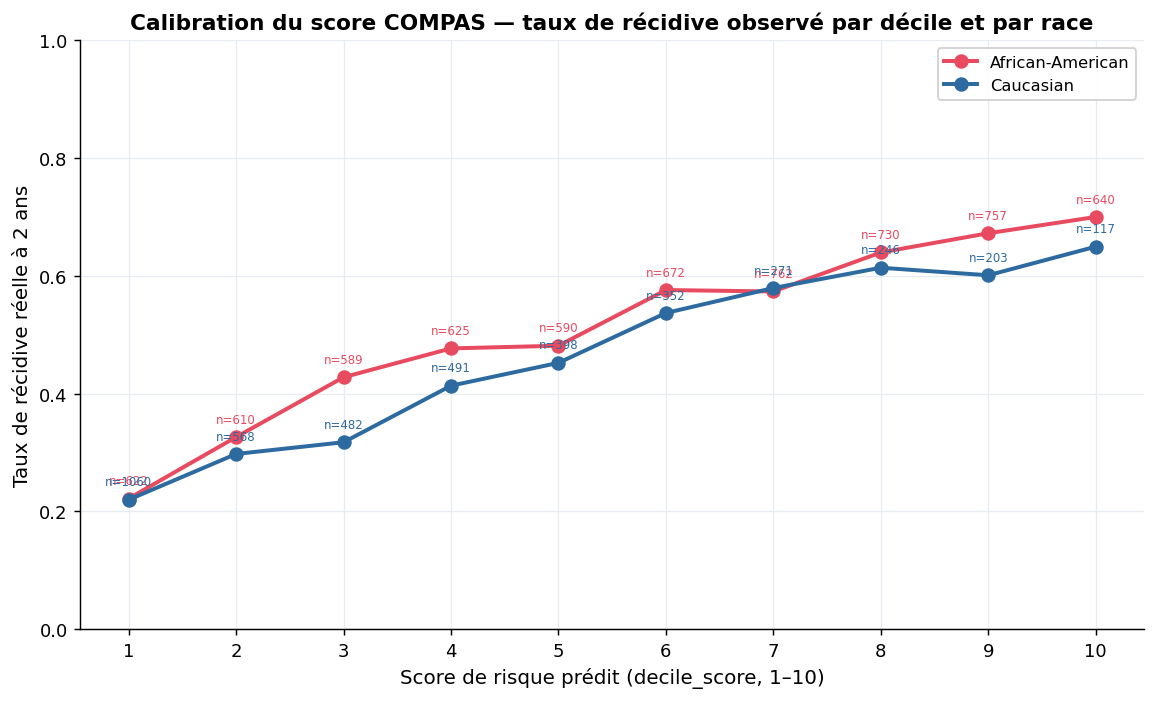

race,African-American,Caucasian
decile_score,,
1,0.22,0.22
2,0.33,0.30
3,0.43,0.32
4,0.48,0.41
5,0.48,0.45
6,0.58,0.54
7,0.57,0.58
8,0.64,0.61
9,0.67,0.60


In [19]:
calib = (
    cox_valid[cox_valid["race"].isin(["African-American", "Caucasian"])]
    .groupby(["race", "decile_score"])["is_recid"]
    .agg(taux_recidive="mean", n="size")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5.5))
for race, color in [("African-American", '#E84A5F'), ("Caucasian", '#2D6A9F')]:
    sub = calib[calib["race"] == race].sort_values("decile_score")
    ax.plot(sub["decile_score"], sub["taux_recidive"],
            marker='o', linewidth=2.2, markersize=7, color=color, label=race)
    for _, row in sub.iterrows():
        ax.annotate(f'n={int(row["n"])}', (row["decile_score"], row["taux_recidive"]),
                    textcoords="offset points", xytext=(0, 8), fontsize=6.5, color=color, ha='center')

ax.set_title("Calibration du score COMPAS — taux de récidive observé par décile et par race",
             fontsize=12, fontweight='bold')
ax.set_xlabel("Score de risque prédit (decile_score, 1–10)")
ax.set_ylabel("Taux de récidive réelle à 2 ans")
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 1)
ax.legend(fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

display(calib.pivot(index="decile_score", columns="race", values="taux_recidive").round(2))


**Lecture :** les deux courbes sont proches l'une de l'autre à la plupart des déciles (ex. décile 1 : 22 % pour les deux groupes ; décile 7 : 57 % vs 58 %), et toutes deux globalement croissantes avec le score — le score est donc **raisonnablement bien calibré entre les deux groupes** : à décile égal, le taux de récidive réelle est proche, avec un léger écart aux extrêmes (décile 10 : 70 % pour les Afro-Américains contre 65 % pour les Caucasiens). C'est ce qui rend le déséquilibre de FPR/FNR observé en 4.3ter d'autant plus notable : il ne provient pas d'une mauvaise calibration du score par groupe, mais bien du théorème d'impossibilité de Chouldechova — à calibration égale, des taux de récidive de base différents entre groupes entraînent mécaniquement des taux d'erreur différents dès qu'on applique un seuil binaire commun (ici, decile_score ≥ 7).

### 4.3ter Taux de classification « haut risque » et erreurs par groupe

On pose un seuil binaire (score ≥ 7 → "haut risque") pour calculer les taux de faux positifs (FPR) et faux négatifs (FNR) par race — les deux métriques au cœur de l'affaire ProPublica.

**Filtrage méthodologique (aligné sur l'étude ProPublica)** : en plus d'exclure `is_recid == -1`, on restreint aux dossiers dont l'écart entre la date d'arrestation et la date de screening COMPAS (`days_b_screening_arrest`) est compris entre -30 et +30 jours, pour ne garder que les charges réellement liées à l'évaluation. ProPublica exclut aussi les simples délits de roulage (`c_charge_degree == 'O'`) : ce code n'existe pas dans cette variante de la table (`c_charge_degree` y est au format `(F3)`, `(M1)`, etc. — degré + sévérité, pas de catégorie « roulage »), ce filtre n'est donc pas applicable ici et n'est pas repris.

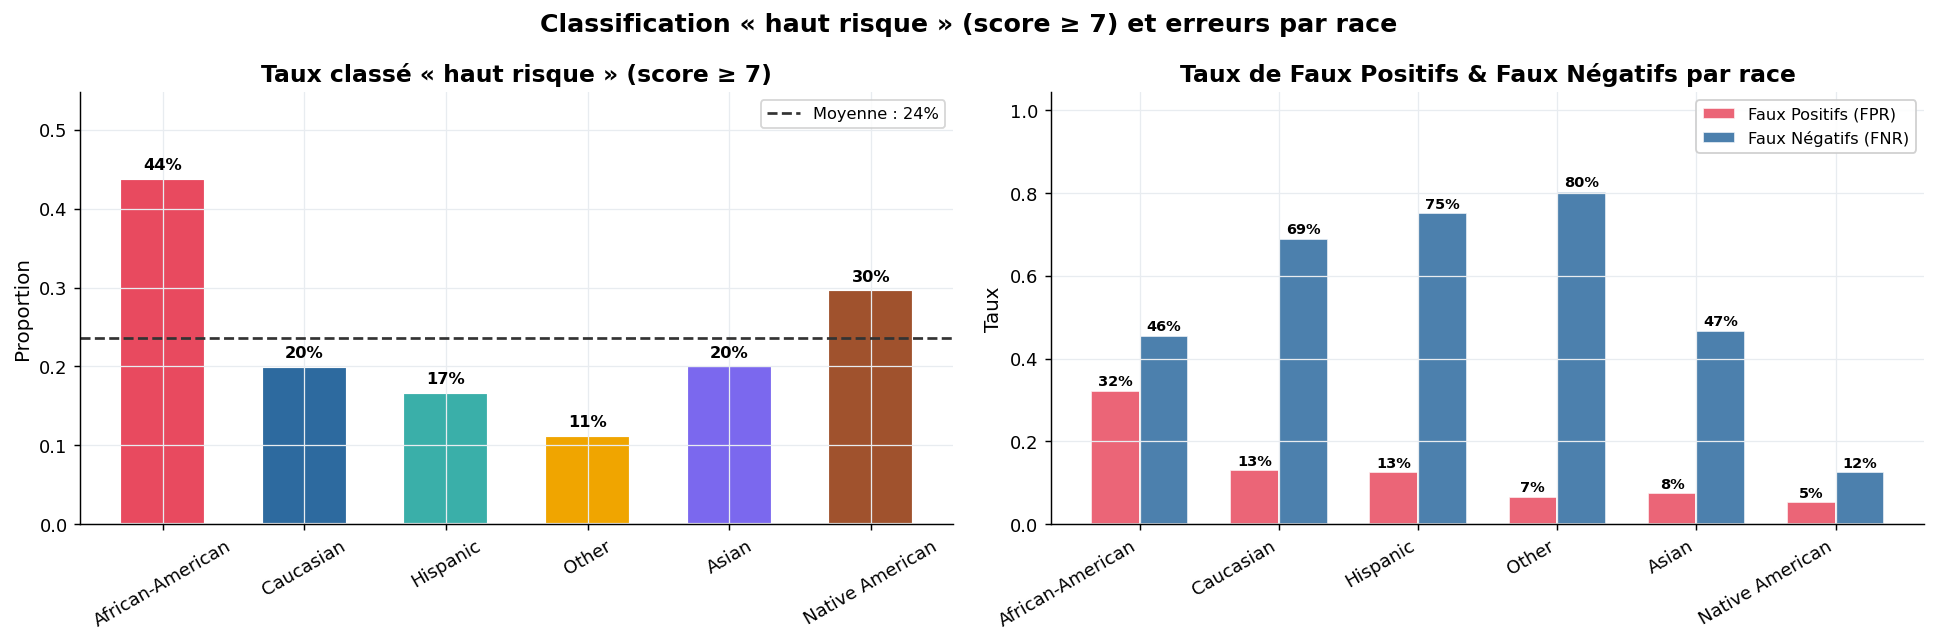


Tableau récapitulatif :


,FPR,FNR,N,Haut risque %,Accuracy
race,,,,,
African-American,0.323,0.456,6597,0.438,0.608
Caucasian,0.130,0.690,4188,0.200,0.652
Hispanic,0.126,0.752,953,0.167,0.664
Other,0.066,0.803,678,0.112,0.674
Asian,0.075,0.467,55,0.200,0.818
Native American,0.053,0.125,27,0.296,0.926


In [20]:
screening_ok = cox_filt["days_b_screening_arrest"].between(-30, 30)
cox_valid = cox_filt[(cox_filt["is_recid"] != -1) & screening_ok & (cox_filt["decile_score"] > 0)
                     & (cox_filt["race"].isin(races_presentes))].copy()
cox_valid["high_risk"] = (cox_valid["decile_score"] >= 7).astype(int)

high_risk_rate = cox_valid.groupby("race")["high_risk"].mean().reindex(races_presentes)

metrics = []
for race in races_presentes:
    df_r = cox_valid[cox_valid["race"] == race]
    fp = ((df_r["high_risk"]==1) & (df_r["is_recid"]==0)).sum()
    fn = ((df_r["high_risk"]==0) & (df_r["is_recid"]==1)).sum()
    tn = ((df_r["high_risk"]==0) & (df_r["is_recid"]==0)).sum()
    tp = ((df_r["high_risk"]==1) & (df_r["is_recid"]==1)).sum()
    fpr = fp/(fp+tn) if (fp+tn)>0 else 0
    fnr = fn/(fn+tp) if (fn+tp)>0 else 0
    accuracy = (tp+tn)/len(df_r) if len(df_r)>0 else 0
    metrics.append({"race": race, "fpr": round(fpr,3), "fnr": round(fnr,3),
                    "n": len(df_r), "selection_rate": round(df_r["high_risk"].mean(),3),
                    "accuracy": round(accuracy,3)})
metrics_df = pd.DataFrame(metrics).set_index("race")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Classification « haut risque » (score ≥ 7) et erreurs par race",
             fontsize=14, fontweight='bold')

# Taux haut risque
bars1 = axes[0].bar(high_risk_rate.index, high_risk_rate.values,
                    color=[RACE_PALETTE.get(r,'#AAAAAA') for r in high_risk_rate.index],
                    edgecolor='white', linewidth=1.2, width=0.6)
axes[0].axhline(high_risk_rate.mean(), color='#333', linewidth=1.5, linestyle='--',
                label=f'Moyenne : {high_risk_rate.mean():.0%}')
for p, v in zip(bars1, high_risk_rate.values):
    axes[0].text(p.get_x()+p.get_width()/2, v+0.008,
                 f'{v:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_title("Taux classé « haut risque » (score ≥ 7)")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, high_risk_rate.max()*1.25)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(fontsize=9)

# FPR / FNR
x = range(len(races_presentes))
w = 0.35
for j, (col, color, label) in enumerate([("fpr","#E84A5F","Faux Positifs (FPR)"),
                                          ("fnr","#2D6A9F","Faux Négatifs (FNR)")]):
    vals = metrics_df[col].reindex(races_presentes).values
    bars2 = axes[1].bar([xi + (j-0.5)*w for xi in x], vals, w,
                        label=label, color=color, edgecolor='white', linewidth=1, alpha=0.85)
    for p, v in zip(bars2, vals):
        if v > 0.02:
            axes[1].text(p.get_x()+p.get_width()/2, v+0.005,
                         f'{v:.0%}', ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_title("Taux de Faux Positifs & Faux Négatifs par race")
axes[1].set_ylabel("Taux")
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(races_presentes, rotation=30, ha='right')
axes[1].legend(fontsize=9, framealpha=0.9)
axes[1].set_ylim(0, metrics_df[["fpr","fnr"]].max().max()*1.3)

plt.tight_layout()
plt.show()
print("\nTableau récapitulatif :")
display(metrics_df.rename(columns={"fpr": "FPR", "fnr": "FNR", "n": "N",
                                    "selection_rate": "Haut risque %", "accuracy": "Accuracy"}))


**Lecture :** le FPR (taux de faux positifs — classés "haut risque" alors qu'ils n'ont pas récidivé) est significativement plus élevé pour les Afro-Américains que pour les Caucasiens. Symétriquement, le FNR (classés "faible risque" alors qu'ils ont récidivé) est plus élevé pour les Caucasiens. C'est exactement l'asymétrie documentée par ProPublica. Ces chiffres seront analysés formellement via les métriques d'équité en Partie 5 (fairlearn).

### 4.3quater Disparités entre groupes — synthèse chiffrée

Écarts maximaux entre tous les groupes, puis focus sur la paire Afro-Américains / Caucasiens.

In [21]:
if not metrics_df.empty:
    demographic_parity_diff = metrics_df["selection_rate"].max() - metrics_df["selection_rate"].min()
    fpr_diff  = metrics_df["fpr"].max()  - metrics_df["fpr"].min()
    fnr_diff  = metrics_df["fnr"].max()  - metrics_df["fnr"].min()

    print("=" * 55)
    print("  DISPARITÉS ENTRE GROUPES (toutes races)")
    print("=" * 55)
    print(f"  Différence de parité démographique  : {demographic_parity_diff:.3f}")
    print(f"  Différence de taux de faux positifs : {fpr_diff:.3f}")
    print(f"  Différence de taux de faux négatifs : {fnr_diff:.3f}")
    print()

    for metric in ["selection_rate", "fpr", "fnr", "accuracy"]:
        if all(g in metrics_df.index for g in ["African-American", "Caucasian"]):
            aa_val   = metrics_df.loc["African-American", metric]
            cauc_val = metrics_df.loc["Caucasian", metric]
            ratio    = aa_val / cauc_val if cauc_val > 0 else float("inf")
            label    = {"selection_rate": "Taux haut risque", "fpr": "Faux Positifs (FPR)",
                        "fnr": "Faux Négatifs (FNR)", "accuracy": "Accuracy"}[metric]
            print(f"  {label}")
            print(f"    Afro-Américains : {aa_val:.3f}")
            print(f"    Caucasiens      : {cauc_val:.3f}")
            print(f"    Ratio           : {ratio:.2f}×")
            print()

  DISPARITÉS ENTRE GROUPES (toutes races)
  Différence de parité démographique  : 0.326
  Différence de taux de faux positifs : 0.270
  Différence de taux de faux négatifs : 0.678

  Taux haut risque
    Afro-Américains : 0.438
    Caucasiens      : 0.200
    Ratio           : 2.19×

  Faux Positifs (FPR)
    Afro-Américains : 0.323
    Caucasiens      : 0.130
    Ratio           : 2.48×

  Faux Négatifs (FNR)
    Afro-Américains : 0.456
    Caucasiens      : 0.690
    Ratio           : 0.66×

  Accuracy
    Afro-Américains : 0.608
    Caucasiens      : 0.652
    Ratio           : 0.93×



**Lecture :** les ratios entre Afro-Américains et Caucasiens révèlent une asymétrie structurelle sur les trois métriques clés. Un ratio FPR > 1 signifie que les Afro-Américains sont davantage classés "haut risque" à tort ; un ratio FNR < 1 signifie que les Caucasiens récidivistes sont davantage sous-estimés. Ces deux erreurs sont les deux faces du biais documenté par ProPublica.

### 4.4 Antécédents judiciaires (`priors_count`) — variable de confusion clé

`priors_count` (nombre d'antécédents) est la variable la plus corrélée au score COMPAS. Or le nombre d'antécédents peut lui-même refléter des biais systémiques dans les taux d'arrestation plutôt que le risque réel de récidive.

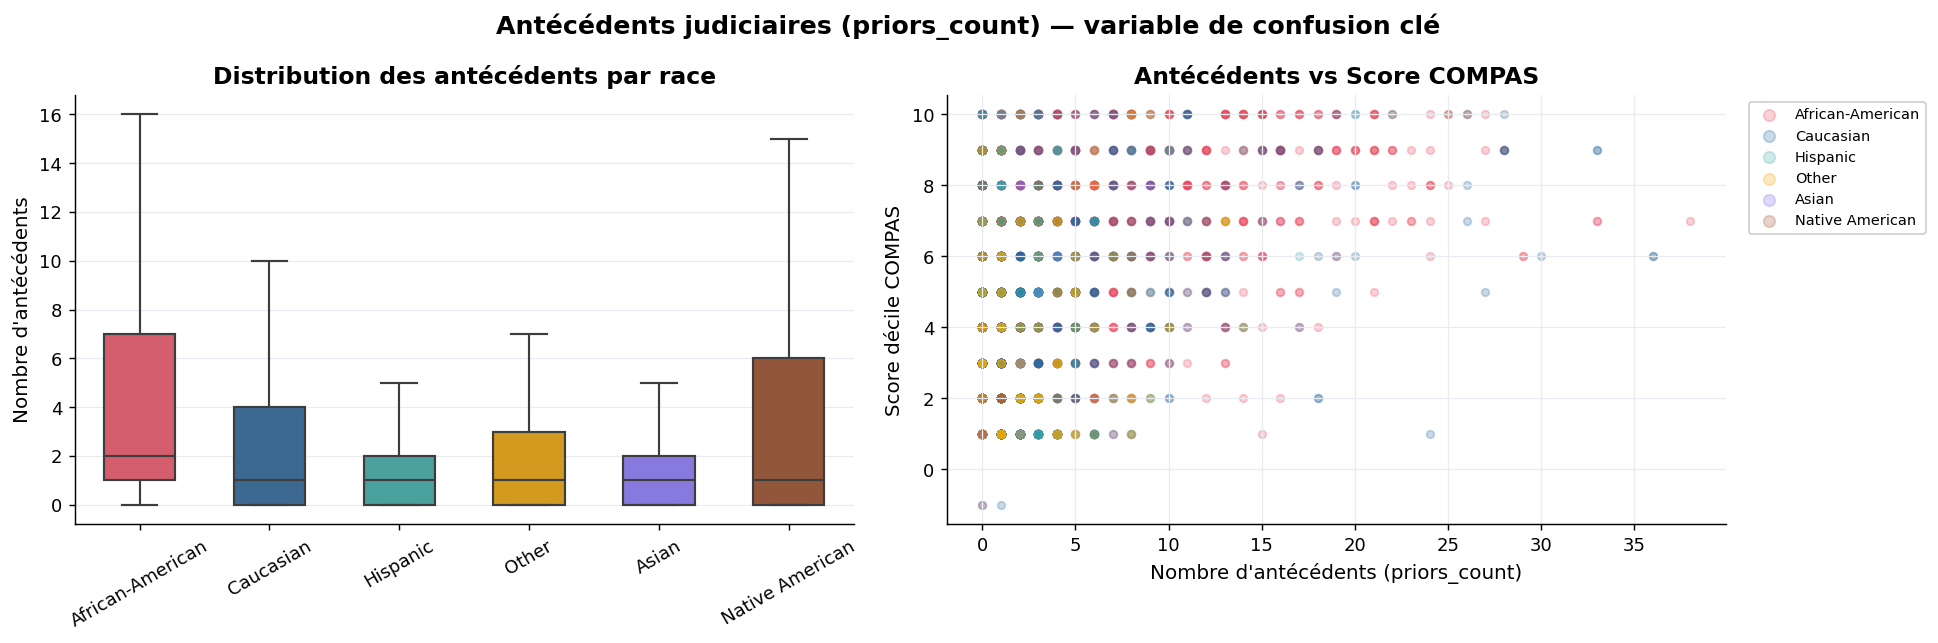

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Antécédents judiciaires (priors_count) — variable de confusion clé",
             fontsize=14, fontweight='bold')

races_box = [r for r in RACE_ORDER if r in cox_filt["race"].unique()]
sns.boxplot(
    data=cox_filt[cox_filt["race"].isin(races_box)],
    x="race", y="priors_count", order=races_box,
    palette=RACE_PALETTE, ax=axes[0], showfliers=False,
    linewidth=1.2, width=0.55,
)
axes[0].set_title("Distribution des antécédents par race")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nombre d'antécédents")
axes[0].tick_params(axis='x', rotation=30)

sample = cox_filt.sample(min(3000, len(cox_filt)), random_state=42)
for race in races_box:
    sub = sample[sample["race"] == race]
    axes[1].scatter(sub["priors_count"], sub["decile_score"],
                    color=RACE_PALETTE.get(race,'#AAAAAA'), alpha=0.25,
                    s=18, label=race)
axes[1].set_title("Antécédents vs Score COMPAS")
axes[1].set_xlabel("Nombre d'antécédents (priors_count)")
axes[1].set_ylabel("Score décile COMPAS")
axes[1].legend(fontsize=8, markerscale=1.5, framealpha=0.9,
               bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()


**Lecture :** le nombre d'antécédents est fortement corrélé au score de risque (relation quasi monotone), ce qui est attendu — c'est l'un des inputs principaux de COMPAS. Mais on observe aussi une **médiane d'antécédents plus élevée** pour le groupe Afro-Américain. Cette variable jouera donc un rôle central (et ambigu) dans l'explicabilité SHAP : elle est prédictive légitimement, mais peut aussi être un vecteur indirect de biais historique — un point à documenter explicitement dans la partie explicabilité/équité.

### 4.5 Corrélations numériques (table 3 — dataset de modélisation)

Dernière vérification comparative : sur la table 3, déjà encodée pour le ML, on regarde la matrice de corrélation pour anticiper les redondances de features avant le feature engineering (partie suivante).

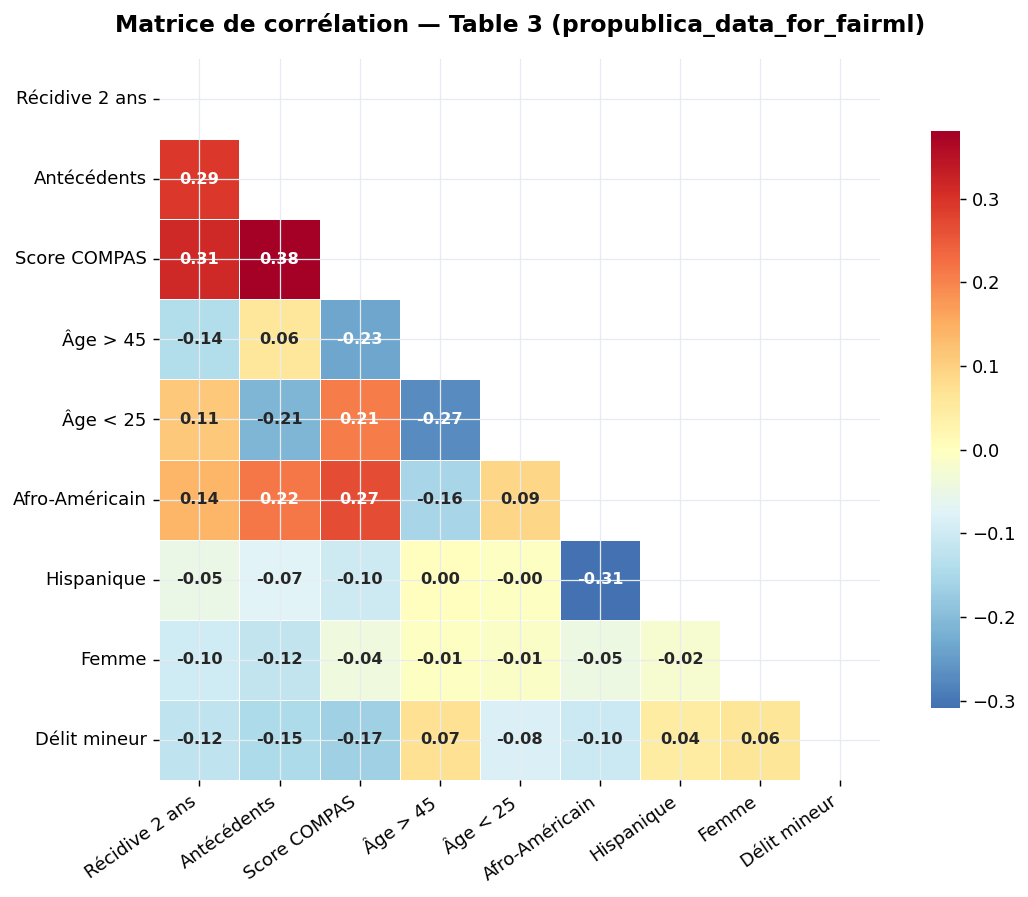

In [23]:
num_cols = ["Two_yr_Recidivism", "Number_of_Priors", "score_factor",
            "Age_Above_FourtyFive", "Age_Below_TwentyFive", "African_American",
            "Hispanic", "Female", "Misdemeanor"]

labels_fr = {
    "Two_yr_Recidivism":   "Récidive 2 ans",
    "Number_of_Priors":    "Antécédents",
    "score_factor":        "Score COMPAS",
    "Age_Above_FourtyFive":"Âge > 45",
    "Age_Below_TwentyFive":"Âge < 25",
    "African_American":    "Afro-Américain",
    "Hispanic":            "Hispanique",
    "Female":              "Femme",
    "Misdemeanor":         "Délit mineur",
}

corr = fairml[num_cols].corr()
corr.index   = [labels_fr[c] for c in corr.index]
corr.columns = [labels_fr[c] for c in corr.columns]

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0,
            square=True, mask=mask, ax=ax,
            linewidths=0.5, linecolor='white',
            annot_kws={"size": 9, "weight": "bold"},
            cbar_kws={"shrink": 0.8})
ax.set_title("Matrice de corrélation — Table 3 (propublica_data_for_fairml)",
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=35, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Lecture :** `score_factor` (score COMPAS binarisé haut/bas) est le plus corrélé à `Number_of_Priors` (r = 0,38), puis à `Two_yr_Recidivism` (r = 0,32), et enfin à `African_American` (r = 0,27). `African_American` reste une variable significativement corrélée au score — indépendamment du nombre d'antécédents — ce que la corrélation seule ne permet pas de décomposer. C'est précisément pour cela que l'analyse SHAP (Partie 4) est nécessaire : isoler la contribution propre de chaque variable au score, au-delà des corrélations brutes.

### 4.6 Métriques d'équité préliminaires

Deux métriques formelles servent de point de départ à l'audit — elles seront approfondies en Partie 5 avec `fairlearn`.

In [24]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

cox_eq = cox_valid[["race", "high_risk", "is_recid"]].dropna()
is_aa = (cox_eq["race"] == "African-American").astype(int)

dpd = demographic_parity_difference(
    y_true=cox_eq["is_recid"],
    y_pred=cox_eq["high_risk"],
    sensitive_features=is_aa
)

eod = equalized_odds_difference(
    y_true=cox_eq["is_recid"],
    y_pred=cox_eq["high_risk"],
    sensitive_features=is_aa
)

# Disparate Impact manuel
rate_aa  = cox_eq[cox_eq["race"] == "African-American"]["high_risk"].mean()
rate_cau = cox_eq[cox_eq["race"] == "Caucasian"]["high_risk"].mean()
di = rate_aa / rate_cau if rate_cau > 0 else float("nan")

print("=" * 55)
print("  MÉTRIQUES D'ÉQUITÉ PRÉLIMINAIRES (Afro-Am. vs Caucasien)")
print("=" * 55)
print(f"  Disparate Impact (DI)              : {di:.3f}")
print(f"    → Seuil acceptable : 0.8 – 1.25")
print(f"    → Interprétation   : {'⚠️  HORS SEUIL' if di < 0.8 or di > 1.25 else '✅ Dans le seuil'}")
print()
print(f"  Demographic Parity Difference      : {dpd:.3f}")
print(f"    → Écart de taux de sélection entre groupes")
print()
print(f"  Equalized Odds Difference          : {eod:.3f}")
print(f"    → Combine FPR et FNR — 0 = équité parfaite")
print("=" * 55)
print("  Ces métriques seront décomposées et corrigées en Partie 5.")

  MÉTRIQUES D'ÉQUITÉ PRÉLIMINAIRES (Afro-Am. vs Caucasien)
  Disparate Impact (DI)              : 2.191
    → Seuil acceptable : 0.8 – 1.25
    → Interprétation   : ⚠️  HORS SEUIL

  Demographic Parity Difference      : 0.253
    → Écart de taux de sélection entre groupes

  Equalized Odds Difference          : 0.252
    → Combine FPR et FNR — 0 = équité parfaite
  Ces métriques seront décomposées et corrigées en Partie 5.


**Lecture :** le Disparate Impact calculé ici vaut **2,19** (rapport du taux de classification « haut risque » Afro-Américain sur celui des Caucasiens) — largement au-dessus du seuil haut de 1,25, et non en dessous de 0,8 : ce sens du ratio s'explique par le fait que « haut risque » est un résultat défavorable, pas un résultat favorable comme dans la définition usuelle du Disparate Impact (ratio de taux de sélection *favorable*). Dans les deux cas le constat est le même : les Afro-Américains sont classés « haut risque » dans une proportion significativement supérieure à celle des Caucasiens, hors du seuil d'équité (0,8 – 1,25). L'Equalized Odds Difference quantifie l'écart combiné de FPR et FNR entre les deux groupes — plus il est éloigné de 0, plus le modèle traite les groupes différemment. Ces deux chiffres posent le cadre formel de l'audit mené en Partie 5.

### 4.6bis Audit d'équité par sexe (FPR/FNR/Disparate Impact)

Le sexe est, comme la race, un attribut protégé : on reproduit ici exactement le même audit (seuil « haut risque » = decile_score ≥ 7, cohorte `cox_valid` déjà filtrée selon la méthodologie ProPublica) mais en comparant **Femmes vs Hommes** plutôt que les groupes ethniques.

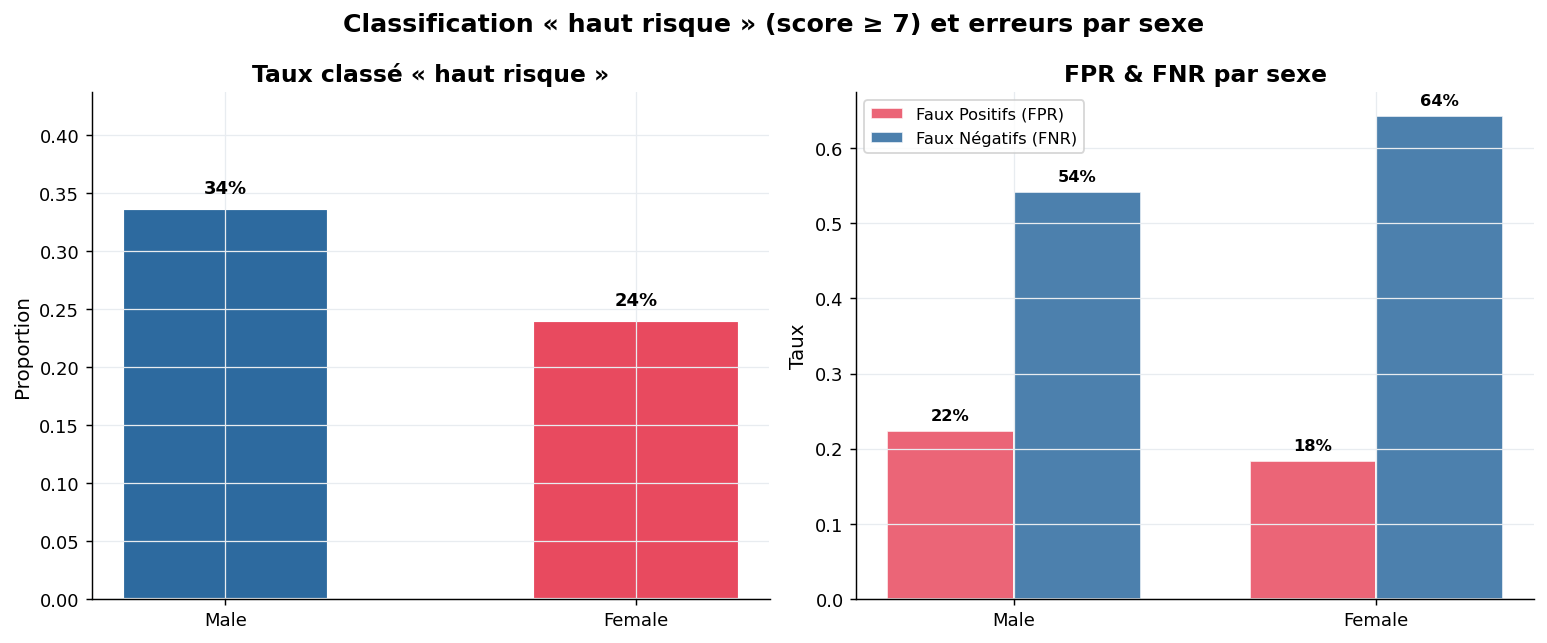

,FPR,FNR,N,Haut risque %,Accuracy
sex,,,,,
Male,0.224,0.541,10162,0.336,0.624
Female,0.184,0.642,2336,0.240,0.668


  MÉTRIQUES D'ÉQUITÉ — SEXE (Femme vs Homme)
  Disparate Impact (DI)              : 0.714
    → Seuil acceptable : 0.8 – 1.25
    → Interprétation   : ⚠️  HORS SEUIL

  Demographic Parity Difference      : 0.096
  Equalized Odds Difference          : 0.101


In [25]:
sex_metrics = []
for sex in ["Male", "Female"]:
    df_s = cox_valid[cox_valid["sex"] == sex]
    fp = ((df_s["high_risk"]==1) & (df_s["is_recid"]==0)).sum()
    fn = ((df_s["high_risk"]==0) & (df_s["is_recid"]==1)).sum()
    tn = ((df_s["high_risk"]==0) & (df_s["is_recid"]==0)).sum()
    tp = ((df_s["high_risk"]==1) & (df_s["is_recid"]==1)).sum()
    fpr = fp/(fp+tn) if (fp+tn)>0 else 0
    fnr = fn/(fn+tp) if (fn+tp)>0 else 0
    acc = (tp+tn)/len(df_s) if len(df_s)>0 else 0
    sex_metrics.append({"sex": sex, "fpr": round(fpr,3), "fnr": round(fnr,3),
                        "n": len(df_s), "selection_rate": round(df_s["high_risk"].mean(),3),
                        "accuracy": round(acc,3)})
sex_metrics_df = pd.DataFrame(sex_metrics).set_index("sex")

sex_colors = {"Male": '#2D6A9F', "Female": '#E84A5F'}

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Classification « haut risque » (score ≥ 7) et erreurs par sexe",
             fontsize=14, fontweight='bold')

bars1 = axes[0].bar(sex_metrics_df.index, sex_metrics_df["selection_rate"],
                    color=[sex_colors[s] for s in sex_metrics_df.index],
                    edgecolor='white', linewidth=1.2, width=0.5)
for p, v in zip(bars1, sex_metrics_df["selection_rate"]):
    axes[0].text(p.get_x()+p.get_width()/2, v+0.01,
                 f'{v:.0%}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].set_title("Taux classé « haut risque »")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, sex_metrics_df["selection_rate"].max()*1.3)

x = range(2)
w = 0.35
for j, (col, color, label) in enumerate([("fpr","#E84A5F","Faux Positifs (FPR)"),
                                          ("fnr","#2D6A9F","Faux Négatifs (FNR)")]):
    vals = sex_metrics_df[col].values
    bars2 = axes[1].bar([xi+(j-0.5)*w for xi in x], vals, w,
                        label=label, color=color, edgecolor='white', linewidth=1, alpha=0.85)
    for p, v in zip(bars2, vals):
        axes[1].text(p.get_x()+p.get_width()/2, v+0.01,
                     f'{v:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[1].set_title("FPR & FNR par sexe")
axes[1].set_xticks(list(x)); axes[1].set_xticklabels(sex_metrics_df.index)
axes[1].set_ylabel("Taux")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

display(sex_metrics_df.rename(columns={"fpr": "FPR", "fnr": "FNR", "n": "N",
                                        "selection_rate": "Haut risque %", "accuracy": "Accuracy"}))

# Disparate Impact / Demographic Parity / Equalized Odds par sexe (Femme vs Homme)
cox_eq_sex = cox_valid[["sex", "high_risk", "is_recid"]].dropna()
is_female = (cox_eq_sex["sex"] == "Female").astype(int)

dpd_sex = demographic_parity_difference(
    y_true=cox_eq_sex["is_recid"], y_pred=cox_eq_sex["high_risk"], sensitive_features=is_female
)
eod_sex = equalized_odds_difference(
    y_true=cox_eq_sex["is_recid"], y_pred=cox_eq_sex["high_risk"], sensitive_features=is_female
)

rate_f = cox_eq_sex[cox_eq_sex["sex"] == "Female"]["high_risk"].mean()
rate_m = cox_eq_sex[cox_eq_sex["sex"] == "Male"]["high_risk"].mean()
di_sex = rate_f / rate_m if rate_m > 0 else float("nan")

print("=" * 55)
print("  MÉTRIQUES D'ÉQUITÉ — SEXE (Femme vs Homme)")
print("=" * 55)
print(f"  Disparate Impact (DI)              : {di_sex:.3f}")
print(f"    → Seuil acceptable : 0.8 – 1.25")
print(f"    → Interprétation   : {'⚠️  HORS SEUIL' if di_sex < 0.8 or di_sex > 1.25 else '✅ Dans le seuil'}")
print()
print(f"  Demographic Parity Difference      : {dpd_sex:.3f}")
print(f"  Equalized Odds Difference          : {eod_sex:.3f}")
print("=" * 55)


**Lecture :** le déséquilibre existe aussi sur le sexe, mais **dans l'autre sens** que sur la race. Les hommes sont classés « haut risque » près de 1,4× plus souvent que les femmes (33,6 % vs 24,0 %), ce qui donne un Disparate Impact de **0,71** — hors du seuil d'équité, mais cette fois **en dessous** de 0,8 (les femmes sont *moins* souvent classées haut risque que les hommes). Le FPR est plus élevé chez les hommes (22,4 % vs 18,4 %), mais le FNR est plus élevé chez les femmes (64,2 % vs 54,1 %) : les femmes qui récidivent réellement sont, proportionnellement, davantage sous-estimées par le score que les hommes. Ce résultat est cohérent avec la littérature sur COMPAS (Skeem & Lowenkamp, 2016) qui documente un score moins bien calibré pour les femmes, dont le taux de récidive de base est plus bas. Le sexe est donc un second axe de disparité à traiter, indépendant de celui observé sur la race.

<a id="5"></a>
## 5. Synthèse intermédiaire

**Ce que l'on retient de cette phase de récupération et d'exploration comparative :**

1. **Les 3 tables sont cohérentes entre elles** sur le plan démographique : table 1 pour la mécanique du score, table 2 pour croiser score/réalité, table 3 comme benchmark simplifié (12 colonnes, score binarisé — la modélisation rigoureuse s'appuiera sur la table 2).
2. **Aucune valeur manquante problématique** — les "trous" de la table 2 sont structurels (absence d'événement) et devront être encodés comme indicatrices binaires.
3. **Premiers signaux de biais potentiel**, cohérents avec l'enquête ProPublica :
   - distribution du score quasi uniforme pour les Afro-Américains vs décroissante pour les Caucasiens ;
   - déséquilibre identique sur le **score violent** (`v_decile_score`) ;
   - le score est **raisonnablement bien calibré** entre les deux groupes (taux de récidive observé proche à décile égal) — ce qui, par le théorème de Chouldechova, rend le déséquilibre d'erreurs ci-dessous d'autant plus significatif : il n'est pas dû à une mauvaise calibration ;
   - FPR significativement plus élevé chez les Afro-Américains, FNR plus élevé chez les Caucasiens ;
   - `priors_count` déséquilibré entre groupes — variable de confusion clé ;
   - **Disparate Impact** préliminaire = 2,19 sur la race (hors du seuil d'équité acceptable 0,8 – 1,25) ;
   - le **sexe** est un second axe de disparité, indépendant de la race : DI = 0,71 (hommes classés « haut risque » ~1,4× plus souvent que les femmes), avec un FNR plus élevé chez les femmes — les deux axes devront être traités (et croisés) dans l'audit d'équité complet.
4. Ces constats **ne permettent pas encore de conclure** à un biais causal — ils orientent précisément le **feature engineering** (Partie 2), la **modélisation** (Partie 3), l'**analyse SHAP** (Partie 4) et l'**audit fairlearn** (Partie 5).

➡️ **Prochaine étape :** Feature Engineering (partie 2).